# Model Training and Transfer Learning




*   CIFAR-10 was trained from scratch using the best hyperparameters. Final validation accuracy after 50 epochs: 91.93%.
*   CIFAR-100 model was initialized using the trained CIFAR-10 weights and fine-tuned. Final validation accuracy after early stopping: 68.48%.

CIFAR-100 model accuracy was also evaluated without transfer learning by training from scratch. The best validation accuracy achieved in that setup was 67.80% (refer to PPar-3_Hyper-parameter-tuning-CIFAR-100.ipynb).


In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def preprocess_cifar(dataset_name='CIFAR100', batch_size=64, val_split=0.2):
    """
    Preprocess CIFAR-10 or CIFAR-100 dataset dynamically.
    :param dataset_name: 'CIFAR10' or 'CIFAR100'
    :param batch_size: Batch size for DataLoader
    :param val_split: Fraction of training data to use for validation
    :return: train_loader, val_loader, test_loader, num_classes
    """
    assert dataset_name in ['CIFAR10', 'CIFAR100'], "Invalid dataset name. Choose CIFAR10 or CIFAR100."

    DatasetClass = getattr(datasets, dataset_name)

    # Load dataset without transformations to calculate mean & std
    dataset = DatasetClass(root='./data', train=True, download=True, transform=transforms.ToTensor())
    data_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

    # Compute mean and std for normalization
    mean = torch.zeros(3)
    std = torch.zeros(3)
    for images, _ in data_loader:
        for i in range(3):
            mean[i] = images[:, i, :, :].mean()
            std[i] = images[:, i, :, :].std()

    print(f"Mean: {mean}")
    print(f"Standard Deviation: {std}")

    # Define transformations
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # Load train & test datasets with transformations
    train_dataset = DatasetClass(root='./data', train=True, download=True, transform=transform_train)
    test_dataset = DatasetClass(root='./data', train=False, download=True, transform=transform_test)

    num_classes = len(train_dataset.classes)

    # One-hot encode labels
    def one_hot_encode(labels, num_classes):
        return F.one_hot(torch.tensor(labels), num_classes=num_classes)

    train_dataset.targets = one_hot_encode(train_dataset.targets, num_classes)
    test_dataset.targets = one_hot_encode(test_dataset.targets, num_classes)

    # Split training data into train & validation
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Training dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")
    print(f"Testing dataset size: {len(test_dataset)}")
    print(f"Number of classes: {num_classes}")

    return train_loader, val_loader, test_loader, num_classes


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, activation=nn.ReLU, use_batchnorm=True):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
        self.activation = activation(inplace=True)

        # If input and output channels are different, use a 1x1 conv to match dimensions
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)  # Residual connection
        out = self.activation(out)
        return out

class CNNModel(nn.Module):
    def __init__(self, num_classes=100, activation=nn.ReLU, use_batchnorm=True, dropout_rate=0.5):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()

        self.res_block1 = ResidualBlock(64, 128, activation=activation, use_batchnorm=use_batchnorm)
        self.res_block2 = ResidualBlock(128, 256, activation=activation, use_batchnorm=use_batchnorm)
        self.res_block3 = ResidualBlock(256, 512, activation=activation, use_batchnorm=use_batchnorm)
        self.res_block4 = ResidualBlock(512, 512, activation=activation, use_batchnorm=use_batchnorm)

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x) if isinstance(self.bn1, nn.Identity) else x
        x = self.res_block1(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = self.res_block2(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = self.res_block3(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = self.res_block4(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, num_epochs=25, lr=0.001, optimizer_type='Adam', use_scheduler=True, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer type. Choose 'Adam' or 'SGD'.")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True) if use_scheduler else None

    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = torch.argmax(targets, dim=1)  # Convert one-hot to class index

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        correct, total = 0, 0
        val_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                targets = torch.argmax(targets, dim=1)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if scheduler:
            scheduler.step(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%")

    # Plotting training progress
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return model


In [ ]:
def run_experiments(
    dataset_name='CIFAR10',
    activation_list=[nn.ReLU, nn.LeakyReLU],
    optimizer_list=['Adam', 'SGD'],
    dropout_rates=[0.3, 0.5],
    learning_rates=[0.001, 0.01],
    num_epochs=20
):

    results = []

    train_loader, val_loader, test_loader, num_classes = preprocess_cifar(dataset_name=dataset_name)

    for activation in activation_list:
        for optimizer_type in optimizer_list:
            for dropout_rate in dropout_rates:
                for lr in learning_rates:
                    print(f"\nRunning: {activation.__name__}, {optimizer_type}, Dropout={dropout_rate}, LR={lr}")

                    model = CNNModel(
                        num_classes=num_classes,
                        activation=activation,
                        use_batchnorm=True,
                        dropout_rate=dropout_rate
                    )

                    trained_model = train_model(
                        model,
                        train_loader,
                        val_loader,
                        num_epochs=num_epochs,
                        lr=lr,
                        optimizer_type=optimizer_type,
                        use_scheduler=True,
                        device=device
                    )

                    # Placeholder: You can improve this by evaluating on test set
                    # Here we only use last validation accuracy
                    val_acc = train_model.val_accuracies[-1] if hasattr(train_model, 'val_accuracies') else None

                    results.append({
                        'activation': activation.__name__,
                        'optimizer': optimizer_type,
                        'dropout_rate': dropout_rate,
                        'learning_rate': lr,
                        'val_accuracy': val_acc
                    })

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by='val_accuracy', ascending=False)
    print("\nTop Results:")
    print(df_results.head())
    return df_results


100%|██████████| 170M/170M [00:03<00:00, 43.7MB/s]


Mean: tensor([0.4914, 0.4822, 0.4465])
Standard Deviation: tensor([0.2470, 0.2435, 0.2616])
Training dataset size: 40000
Validation dataset size: 10000
Testing dataset size: 10000
Number of classes: 10

Running: ReLU, Adam, Dropout=0.3, LR=0.001


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/20] - Train Loss: 1.4667 - Val Loss: 1.2108 - Val Acc: 58.22%
Epoch [2/20] - Train Loss: 0.9848 - Val Loss: 1.1508 - Val Acc: 62.72%
Epoch [3/20] - Train Loss: 0.7856 - Val Loss: 0.7733 - Val Acc: 73.30%
Epoch [4/20] - Train Loss: 0.6604 - Val Loss: 0.7362 - Val Acc: 75.45%
Epoch [5/20] - Train Loss: 0.5740 - Val Loss: 0.6241 - Val Acc: 78.32%
Epoch [6/20] - Train Loss: 0.5071 - Val Loss: 0.7149 - Val Acc: 75.51%
Epoch [7/20] - Train Loss: 0.4574 - Val Loss: 0.6003 - Val Acc: 79.06%
Epoch [8/20] - Train Loss: 0.4104 - Val Loss: 0.4397 - Val Acc: 84.92%
Epoch [9/20] - Train Loss: 0.3728 - Val Loss: 0.4227 - Val Acc: 85.66%
Epoch [10/20] - Train Loss: 0.3406 - Val Loss: 0.4224 - Val Acc: 85.71%
Epoch [11/20] - Train Loss: 0.3133 - Val Loss: 0.3876 - Val Acc: 87.23%
Epoch [12/20] - Train Loss: 0.2833 - Val Loss: 0.4333 - Val Acc: 85.47%
Epoch [13/20] - Train Loss: 0.2624 - Val Loss: 0.4003 - Val Acc: 86.76%
Epoch [14/20] - Train Loss: 0.2341 - Val Loss: 0.3868 - Val Acc: 87.42%
E

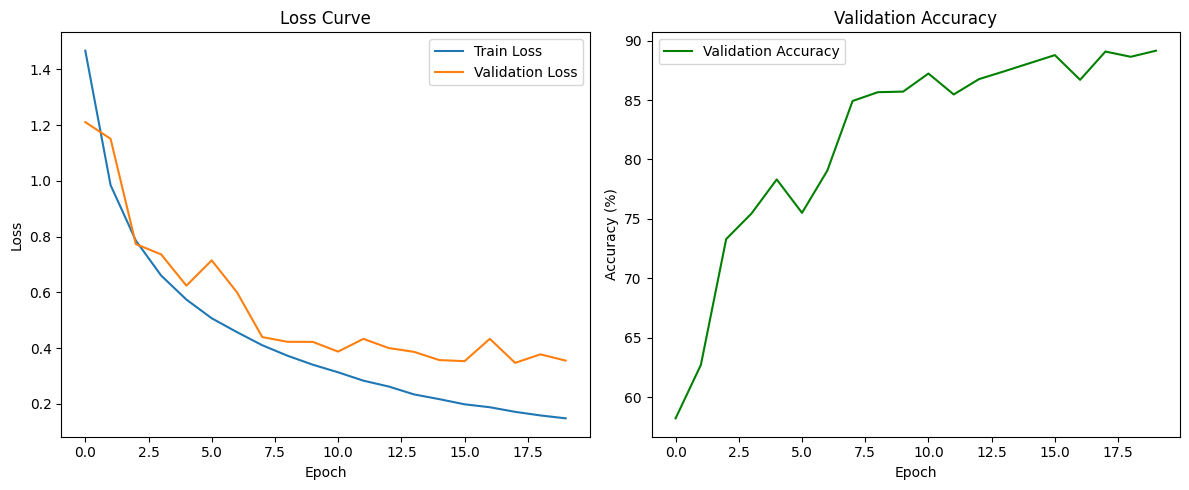


Running: ReLU, Adam, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 1.7671 - Val Loss: 1.3057 - Val Acc: 52.87%
Epoch [2/20] - Train Loss: 1.1028 - Val Loss: 1.1002 - Val Acc: 61.25%
Epoch [3/20] - Train Loss: 0.8592 - Val Loss: 0.8715 - Val Acc: 70.11%
Epoch [4/20] - Train Loss: 0.6994 - Val Loss: 0.6730 - Val Acc: 76.43%
Epoch [5/20] - Train Loss: 0.6071 - Val Loss: 0.7516 - Val Acc: 75.42%
Epoch [6/20] - Train Loss: 0.5372 - Val Loss: 0.5925 - Val Acc: 79.79%
Epoch [7/20] - Train Loss: 0.4902 - Val Loss: 0.5368 - Val Acc: 81.99%
Epoch [8/20] - Train Loss: 0.4485 - Val Loss: 0.5735 - Val Acc: 80.49%
Epoch [9/20] - Train Loss: 0.4101 - Val Loss: 0.5048 - Val Acc: 82.92%
Epoch [10/20] - Train Loss: 0.3814 - Val Loss: 0.4191 - Val Acc: 85.73%
Epoch [11/20] - Train Loss: 0.3512 - Val Loss: 0.4490 - Val Acc: 85.36%
Epoch [12/20] - Train Loss: 0.3267 - Val Loss: 0.4209 - Val Acc: 86.69%
Epoch [13/20] - Train Loss: 0.3022 - Val Loss: 0.4247 - Val Acc: 86.17%
Epoch [14/20] - Train Loss: 0.

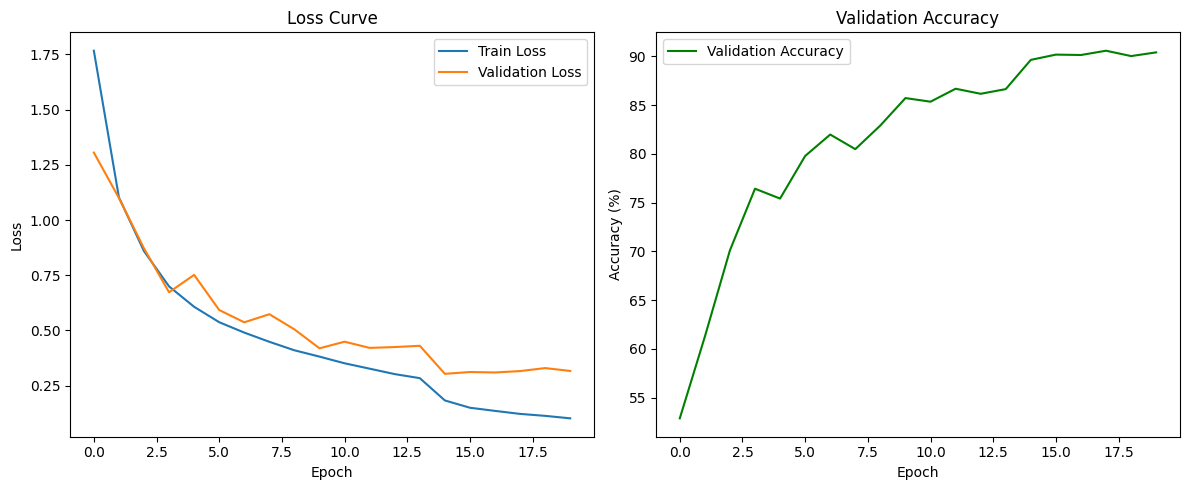


Running: ReLU, Adam, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 1.5179 - Val Loss: 1.2146 - Val Acc: 57.78%
Epoch [2/20] - Train Loss: 1.0128 - Val Loss: 0.9613 - Val Acc: 67.05%
Epoch [3/20] - Train Loss: 0.7999 - Val Loss: 0.7870 - Val Acc: 72.37%
Epoch [4/20] - Train Loss: 0.6766 - Val Loss: 0.6374 - Val Acc: 77.91%
Epoch [5/20] - Train Loss: 0.5893 - Val Loss: 0.6079 - Val Acc: 79.28%
Epoch [6/20] - Train Loss: 0.5257 - Val Loss: 0.5064 - Val Acc: 82.58%
Epoch [7/20] - Train Loss: 0.4735 - Val Loss: 0.5027 - Val Acc: 82.65%
Epoch [8/20] - Train Loss: 0.4259 - Val Loss: 0.4707 - Val Acc: 83.72%
Epoch [9/20] - Train Loss: 0.3928 - Val Loss: 0.4905 - Val Acc: 83.52%
Epoch [10/20] - Train Loss: 0.3532 - Val Loss: 0.3922 - Val Acc: 87.00%
Epoch [11/20] - Train Loss: 0.3259 - Val Loss: 0.4064 - Val Acc: 85.91%
Epoch [12/20] - Train Loss: 0.2993 - Val Loss: 0.4232 - Val Acc: 86.23%
Epoch [13/20] - Train Loss: 0.2759 - Val Loss: 0.4419 - Val Acc: 85.39%
Epoch [14/20] - Train Loss: 0

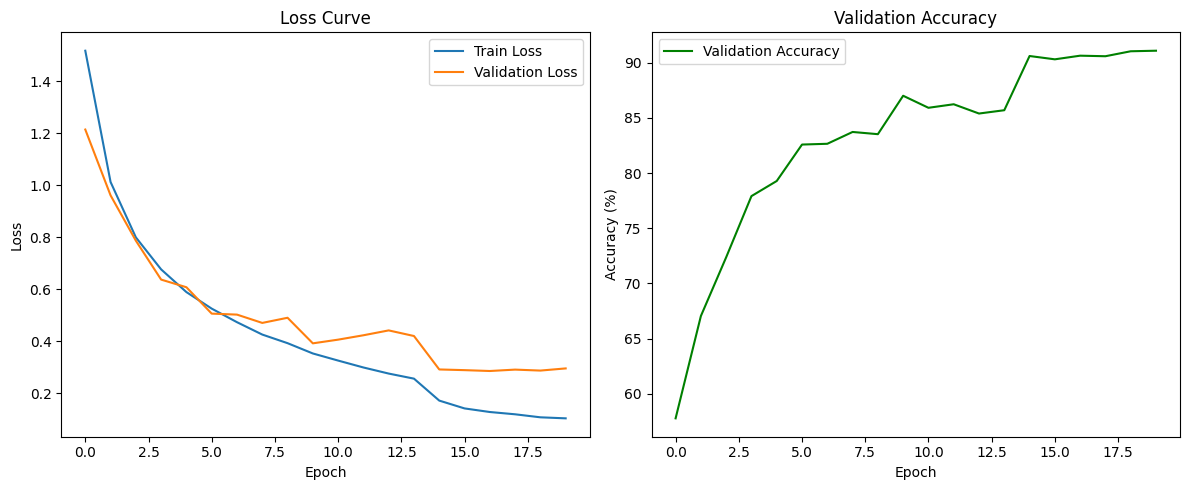


Running: ReLU, Adam, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 1.8679 - Val Loss: 1.3993 - Val Acc: 49.61%
Epoch [2/20] - Train Loss: 1.1771 - Val Loss: 1.0299 - Val Acc: 64.21%
Epoch [3/20] - Train Loss: 0.8939 - Val Loss: 0.9037 - Val Acc: 68.36%
Epoch [4/20] - Train Loss: 0.7312 - Val Loss: 0.6951 - Val Acc: 75.73%
Epoch [5/20] - Train Loss: 0.6438 - Val Loss: 0.8369 - Val Acc: 72.21%
Epoch [6/20] - Train Loss: 0.5730 - Val Loss: 0.6251 - Val Acc: 78.91%
Epoch [7/20] - Train Loss: 0.5246 - Val Loss: 0.5118 - Val Acc: 82.73%
Epoch [8/20] - Train Loss: 0.4777 - Val Loss: 0.5636 - Val Acc: 81.17%
Epoch [9/20] - Train Loss: 0.4416 - Val Loss: 0.4861 - Val Acc: 84.02%
Epoch [10/20] - Train Loss: 0.4072 - Val Loss: 0.4907 - Val Acc: 83.14%
Epoch [11/20] - Train Loss: 0.3832 - Val Loss: 0.4808 - Val Acc: 84.50%
Epoch [12/20] - Train Loss: 0.3588 - Val Loss: 0.4898 - Val Acc: 83.94%
Epoch [13/20] - Train Loss: 0.3290 - Val Loss: 0.4311 - Val Acc: 86.32%
Epoch [14/20] - Train Loss: 0.

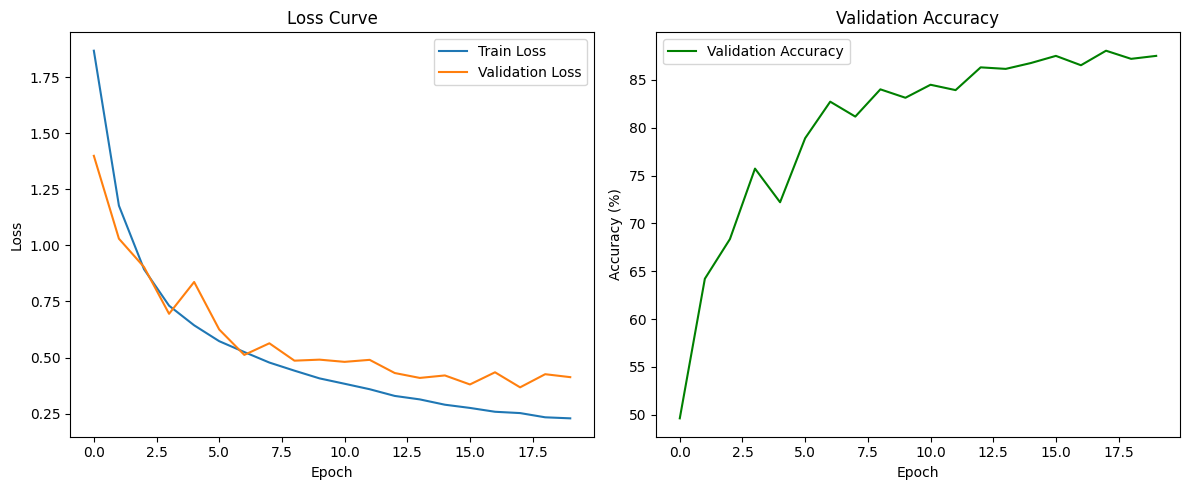


Running: ReLU, SGD, Dropout=0.3, LR=0.001
Epoch [1/20] - Train Loss: 1.5336 - Val Loss: 1.2015 - Val Acc: 56.58%
Epoch [2/20] - Train Loss: 1.0917 - Val Loss: 0.9865 - Val Acc: 65.23%
Epoch [3/20] - Train Loss: 0.8999 - Val Loss: 0.8875 - Val Acc: 68.70%
Epoch [4/20] - Train Loss: 0.8023 - Val Loss: 0.7835 - Val Acc: 72.93%
Epoch [5/20] - Train Loss: 0.7236 - Val Loss: 0.7567 - Val Acc: 74.20%
Epoch [6/20] - Train Loss: 0.6560 - Val Loss: 0.7252 - Val Acc: 74.68%
Epoch [7/20] - Train Loss: 0.6186 - Val Loss: 0.8547 - Val Acc: 71.09%
Epoch [8/20] - Train Loss: 0.5724 - Val Loss: 0.6146 - Val Acc: 78.43%
Epoch [9/20] - Train Loss: 0.5427 - Val Loss: 0.5960 - Val Acc: 79.67%
Epoch [10/20] - Train Loss: 0.5124 - Val Loss: 0.6818 - Val Acc: 77.07%
Epoch [11/20] - Train Loss: 0.4832 - Val Loss: 0.5421 - Val Acc: 81.44%
Epoch [12/20] - Train Loss: 0.4631 - Val Loss: 0.5198 - Val Acc: 81.67%
Epoch [13/20] - Train Loss: 0.4347 - Val Loss: 0.5203 - Val Acc: 82.40%
Epoch [14/20] - Train Loss: 0.

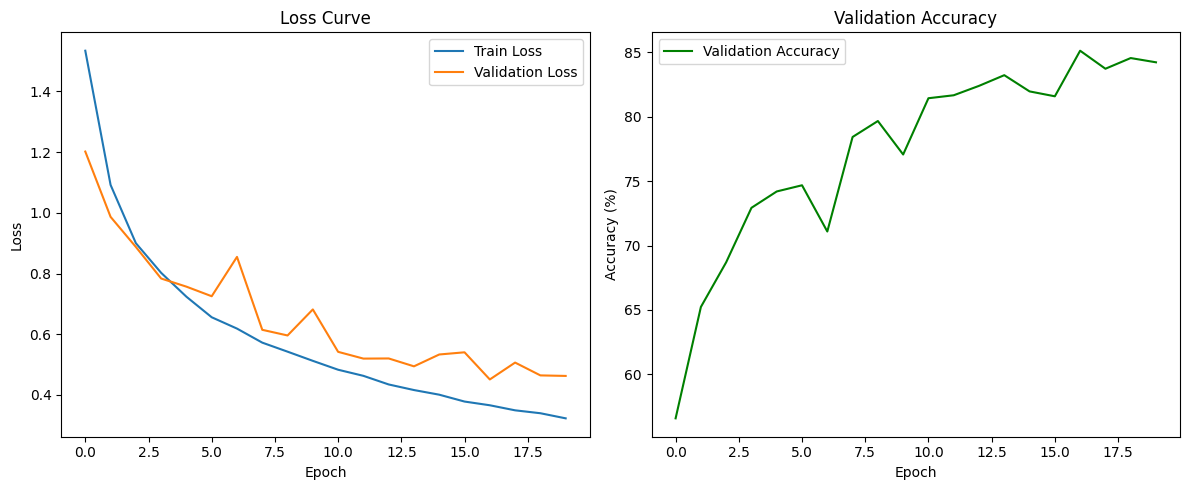


Running: ReLU, SGD, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 1.5637 - Val Loss: 1.3986 - Val Acc: 50.85%
Epoch [2/20] - Train Loss: 1.0344 - Val Loss: 0.9097 - Val Acc: 67.83%
Epoch [3/20] - Train Loss: 0.8364 - Val Loss: 0.8199 - Val Acc: 72.10%
Epoch [4/20] - Train Loss: 0.7271 - Val Loss: 0.7164 - Val Acc: 75.41%
Epoch [5/20] - Train Loss: 0.6375 - Val Loss: 0.6473 - Val Acc: 78.60%
Epoch [6/20] - Train Loss: 0.5617 - Val Loss: 0.6280 - Val Acc: 78.95%
Epoch [7/20] - Train Loss: 0.5199 - Val Loss: 0.5749 - Val Acc: 79.95%
Epoch [8/20] - Train Loss: 0.4750 - Val Loss: 0.6215 - Val Acc: 79.06%
Epoch [9/20] - Train Loss: 0.4429 - Val Loss: 0.5079 - Val Acc: 83.13%
Epoch [10/20] - Train Loss: 0.4126 - Val Loss: 0.4854 - Val Acc: 83.87%
Epoch [11/20] - Train Loss: 0.3763 - Val Loss: 0.4419 - Val Acc: 85.41%
Epoch [12/20] - Train Loss: 0.3530 - Val Loss: 0.4506 - Val Acc: 84.82%
Epoch [13/20] - Train Loss: 0.3303 - Val Loss: 0.4086 - Val Acc: 86.28%
Epoch [14/20] - Train Loss: 0.3

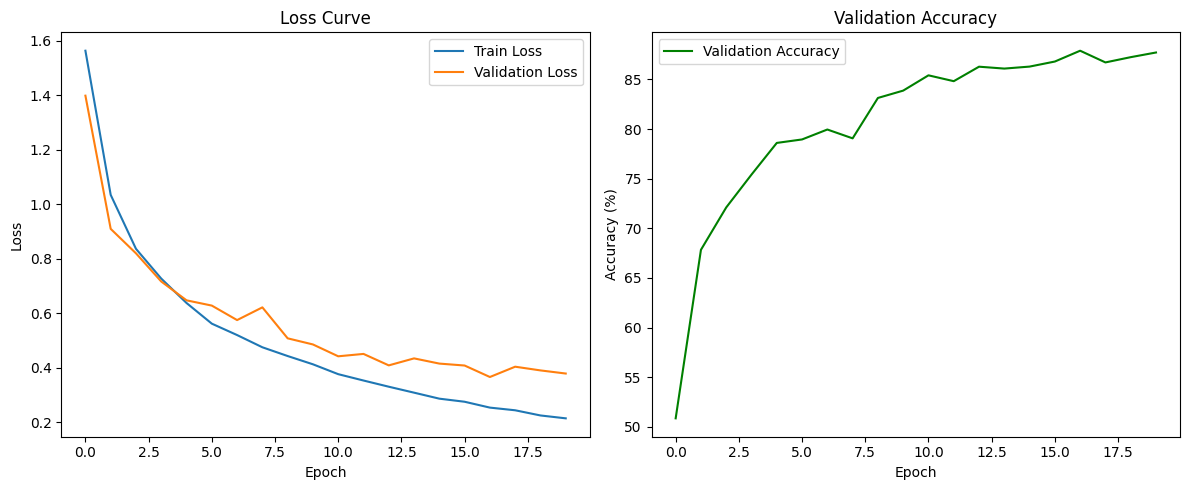


Running: ReLU, SGD, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 1.6504 - Val Loss: 1.3211 - Val Acc: 52.78%
Epoch [2/20] - Train Loss: 1.1828 - Val Loss: 1.0123 - Val Acc: 64.49%
Epoch [3/20] - Train Loss: 0.9859 - Val Loss: 1.0681 - Val Acc: 63.54%
Epoch [4/20] - Train Loss: 0.8697 - Val Loss: 0.7519 - Val Acc: 73.18%
Epoch [5/20] - Train Loss: 0.7812 - Val Loss: 0.7365 - Val Acc: 74.04%
Epoch [6/20] - Train Loss: 0.7239 - Val Loss: 0.6946 - Val Acc: 75.26%
Epoch [7/20] - Train Loss: 0.6694 - Val Loss: 0.6400 - Val Acc: 77.84%
Epoch [8/20] - Train Loss: 0.6209 - Val Loss: 0.7191 - Val Acc: 75.56%
Epoch [9/20] - Train Loss: 0.5869 - Val Loss: 0.7740 - Val Acc: 73.10%
Epoch [10/20] - Train Loss: 0.5513 - Val Loss: 0.5965 - Val Acc: 79.59%
Epoch [11/20] - Train Loss: 0.5294 - Val Loss: 0.5669 - Val Acc: 80.14%
Epoch [12/20] - Train Loss: 0.5001 - Val Loss: 0.5910 - Val Acc: 79.85%
Epoch [13/20] - Train Loss: 0.4787 - Val Loss: 0.5612 - Val Acc: 80.78%
Epoch [14/20] - Train Loss: 0.

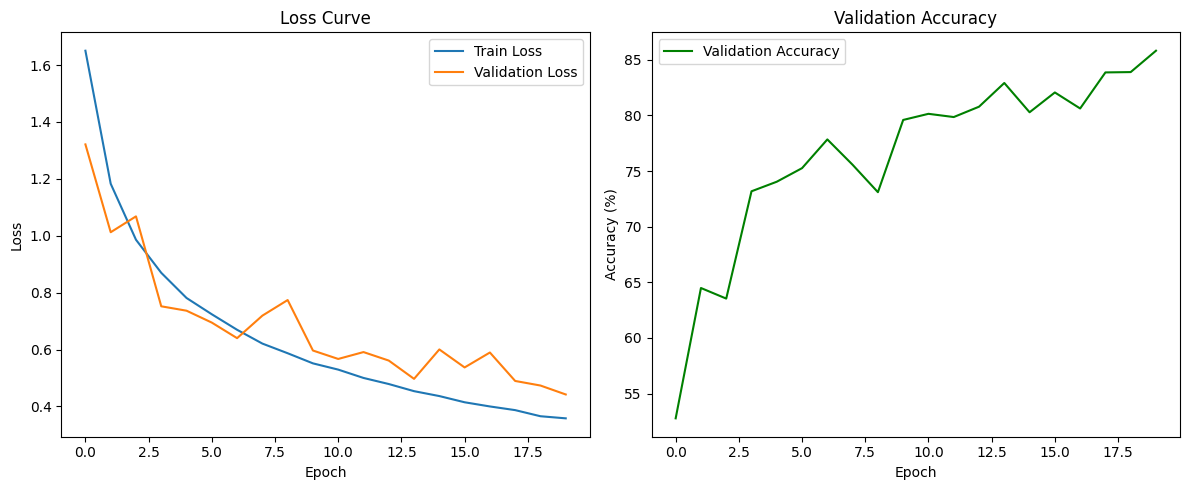


Running: ReLU, SGD, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 1.6753 - Val Loss: 1.2633 - Val Acc: 54.36%
Epoch [2/20] - Train Loss: 1.1123 - Val Loss: 0.9380 - Val Acc: 67.44%
Epoch [3/20] - Train Loss: 0.8982 - Val Loss: 0.8857 - Val Acc: 69.06%
Epoch [4/20] - Train Loss: 0.7599 - Val Loss: 0.7635 - Val Acc: 74.21%
Epoch [5/20] - Train Loss: 0.6619 - Val Loss: 0.6319 - Val Acc: 77.98%
Epoch [6/20] - Train Loss: 0.5899 - Val Loss: 0.5969 - Val Acc: 79.51%
Epoch [7/20] - Train Loss: 0.5479 - Val Loss: 0.5098 - Val Acc: 82.50%
Epoch [8/20] - Train Loss: 0.4953 - Val Loss: 0.5355 - Val Acc: 82.53%
Epoch [9/20] - Train Loss: 0.4534 - Val Loss: 0.4985 - Val Acc: 83.34%
Epoch [10/20] - Train Loss: 0.4242 - Val Loss: 0.4643 - Val Acc: 83.95%
Epoch [11/20] - Train Loss: 0.3912 - Val Loss: 0.4410 - Val Acc: 85.21%
Epoch [12/20] - Train Loss: 0.3630 - Val Loss: 0.4778 - Val Acc: 83.99%
Epoch [13/20] - Train Loss: 0.3446 - Val Loss: 0.4007 - Val Acc: 86.86%
Epoch [14/20] - Train Loss: 0.3

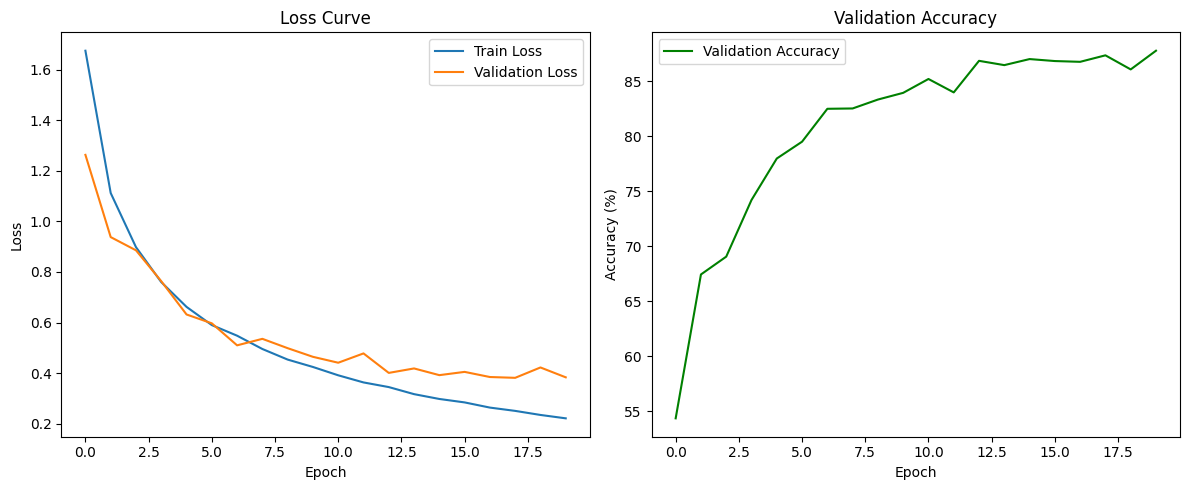


Running: LeakyReLU, Adam, Dropout=0.3, LR=0.001
Epoch [1/20] - Train Loss: 1.4981 - Val Loss: 1.1709 - Val Acc: 58.28%
Epoch [2/20] - Train Loss: 0.9788 - Val Loss: 0.9150 - Val Acc: 68.29%
Epoch [3/20] - Train Loss: 0.7784 - Val Loss: 0.8460 - Val Acc: 70.89%
Epoch [4/20] - Train Loss: 0.6627 - Val Loss: 0.6431 - Val Acc: 77.73%
Epoch [5/20] - Train Loss: 0.5838 - Val Loss: 0.5682 - Val Acc: 80.99%
Epoch [6/20] - Train Loss: 0.5199 - Val Loss: 0.5781 - Val Acc: 80.65%
Epoch [7/20] - Train Loss: 0.4643 - Val Loss: 0.5525 - Val Acc: 81.48%
Epoch [8/20] - Train Loss: 0.4243 - Val Loss: 0.5035 - Val Acc: 82.91%
Epoch [9/20] - Train Loss: 0.3833 - Val Loss: 0.4653 - Val Acc: 84.24%
Epoch [10/20] - Train Loss: 0.3488 - Val Loss: 0.4408 - Val Acc: 85.05%
Epoch [11/20] - Train Loss: 0.3227 - Val Loss: 0.3816 - Val Acc: 87.54%
Epoch [12/20] - Train Loss: 0.2915 - Val Loss: 0.3775 - Val Acc: 87.78%
Epoch [13/20] - Train Loss: 0.2721 - Val Loss: 0.4075 - Val Acc: 86.69%
Epoch [14/20] - Train Lo

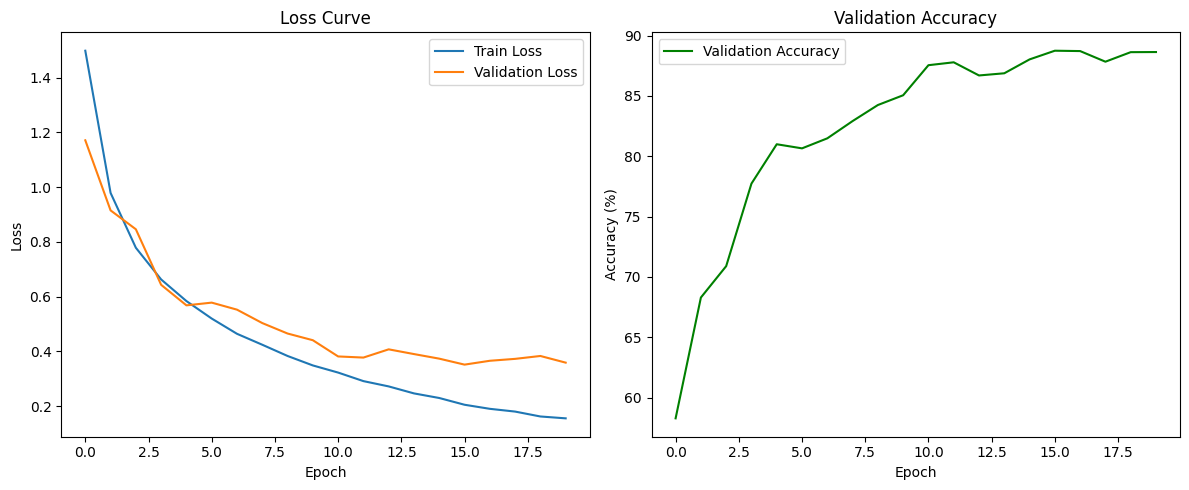


Running: LeakyReLU, Adam, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 1.7941 - Val Loss: 1.3664 - Val Acc: 49.73%
Epoch [2/20] - Train Loss: 1.1233 - Val Loss: 1.0255 - Val Acc: 63.42%
Epoch [3/20] - Train Loss: 0.8648 - Val Loss: 0.9276 - Val Acc: 68.40%
Epoch [4/20] - Train Loss: 0.6998 - Val Loss: 0.6890 - Val Acc: 75.85%
Epoch [5/20] - Train Loss: 0.6084 - Val Loss: 0.7268 - Val Acc: 74.71%
Epoch [6/20] - Train Loss: 0.5431 - Val Loss: 0.5339 - Val Acc: 81.55%
Epoch [7/20] - Train Loss: 0.4893 - Val Loss: 0.4821 - Val Acc: 83.19%
Epoch [8/20] - Train Loss: 0.4417 - Val Loss: 0.4826 - Val Acc: 83.28%
Epoch [9/20] - Train Loss: 0.4114 - Val Loss: 0.4698 - Val Acc: 84.22%
Epoch [10/20] - Train Loss: 0.3774 - Val Loss: 0.5522 - Val Acc: 81.76%
Epoch [11/20] - Train Loss: 0.3476 - Val Loss: 0.5039 - Val Acc: 83.02%
Epoch [12/20] - Train Loss: 0.3185 - Val Loss: 0.5010 - Val Acc: 84.47%
Epoch [13/20] - Train Loss: 0.3067 - Val Loss: 0.4557 - Val Acc: 85.57%
Epoch [14/20] - Train Los

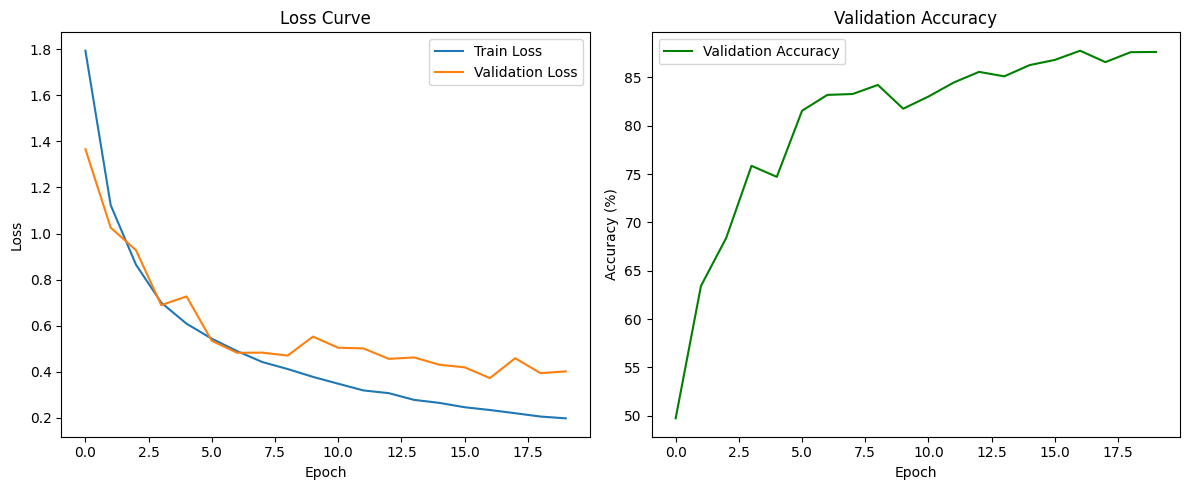


Running: LeakyReLU, Adam, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 1.5259 - Val Loss: 1.1566 - Val Acc: 57.42%
Epoch [2/20] - Train Loss: 0.9928 - Val Loss: 0.9379 - Val Acc: 66.75%
Epoch [3/20] - Train Loss: 0.7973 - Val Loss: 0.7960 - Val Acc: 72.13%
Epoch [4/20] - Train Loss: 0.6742 - Val Loss: 0.6900 - Val Acc: 75.94%
Epoch [5/20] - Train Loss: 0.5908 - Val Loss: 0.6265 - Val Acc: 78.89%
Epoch [6/20] - Train Loss: 0.5300 - Val Loss: 0.5065 - Val Acc: 82.78%
Epoch [7/20] - Train Loss: 0.4739 - Val Loss: 0.5314 - Val Acc: 81.47%
Epoch [8/20] - Train Loss: 0.4348 - Val Loss: 0.4790 - Val Acc: 83.95%
Epoch [9/20] - Train Loss: 0.3965 - Val Loss: 0.4607 - Val Acc: 84.19%
Epoch [10/20] - Train Loss: 0.3588 - Val Loss: 0.4307 - Val Acc: 85.53%
Epoch [11/20] - Train Loss: 0.3293 - Val Loss: 0.4214 - Val Acc: 85.99%
Epoch [12/20] - Train Loss: 0.3039 - Val Loss: 0.3764 - Val Acc: 87.06%
Epoch [13/20] - Train Loss: 0.2817 - Val Loss: 0.3984 - Val Acc: 86.74%
Epoch [14/20] - Train Lo

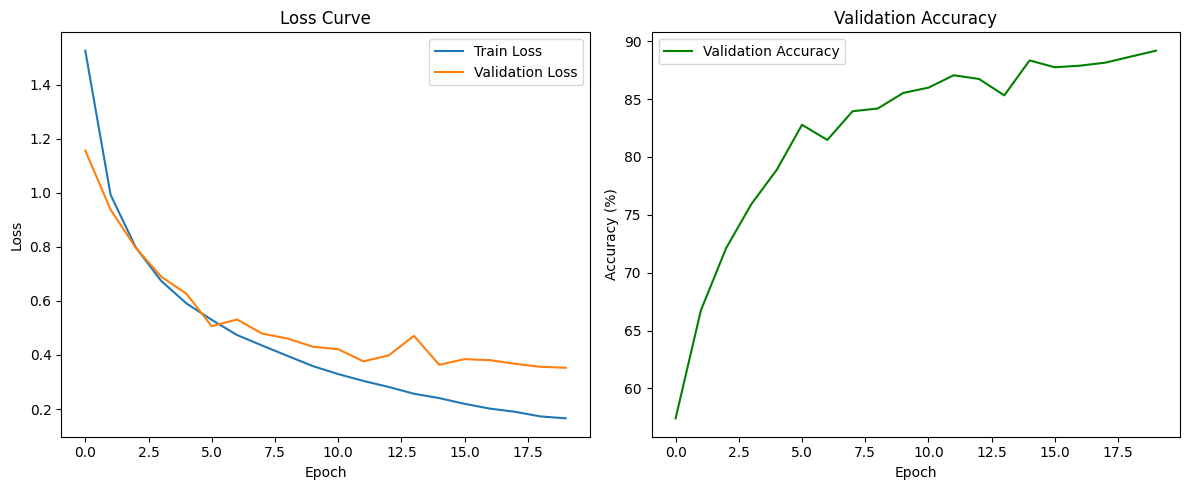


Running: LeakyReLU, Adam, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 1.8057 - Val Loss: 1.3586 - Val Acc: 51.48%
Epoch [2/20] - Train Loss: 1.1806 - Val Loss: 1.1663 - Val Acc: 60.73%
Epoch [3/20] - Train Loss: 0.9383 - Val Loss: 0.8036 - Val Acc: 72.15%
Epoch [4/20] - Train Loss: 0.7650 - Val Loss: 0.7203 - Val Acc: 75.08%
Epoch [5/20] - Train Loss: 0.6566 - Val Loss: 0.6458 - Val Acc: 77.76%
Epoch [6/20] - Train Loss: 0.5890 - Val Loss: 0.7463 - Val Acc: 75.95%
Epoch [7/20] - Train Loss: 0.5293 - Val Loss: 0.5391 - Val Acc: 81.44%
Epoch [8/20] - Train Loss: 0.4916 - Val Loss: 0.5627 - Val Acc: 81.68%
Epoch [9/20] - Train Loss: 0.4546 - Val Loss: 0.5364 - Val Acc: 81.90%
Epoch [10/20] - Train Loss: 0.4157 - Val Loss: 0.5269 - Val Acc: 82.47%
Epoch [11/20] - Train Loss: 0.3883 - Val Loss: 0.4648 - Val Acc: 84.49%
Epoch [12/20] - Train Loss: 0.3640 - Val Loss: 0.4666 - Val Acc: 84.61%
Epoch [13/20] - Train Loss: 0.3446 - Val Loss: 0.4317 - Val Acc: 85.66%
Epoch [14/20] - Train Los

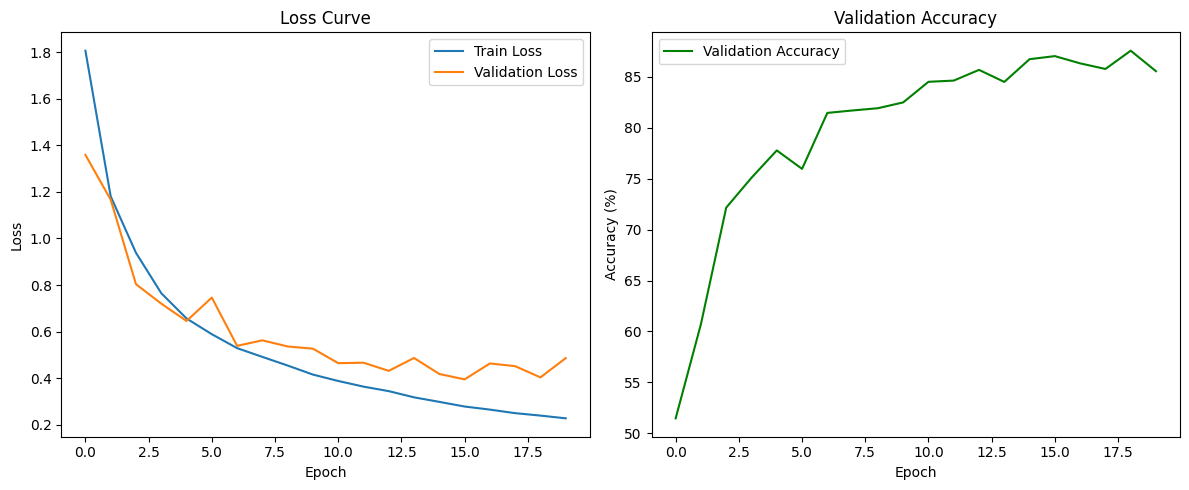


Running: LeakyReLU, SGD, Dropout=0.3, LR=0.001
Epoch [1/20] - Train Loss: 1.5349 - Val Loss: 1.2468 - Val Acc: 53.53%
Epoch [2/20] - Train Loss: 1.0897 - Val Loss: 0.9557 - Val Acc: 66.44%
Epoch [3/20] - Train Loss: 0.9127 - Val Loss: 0.8397 - Val Acc: 70.61%
Epoch [4/20] - Train Loss: 0.7998 - Val Loss: 0.8725 - Val Acc: 70.02%
Epoch [5/20] - Train Loss: 0.7207 - Val Loss: 0.7139 - Val Acc: 75.29%
Epoch [6/20] - Train Loss: 0.6657 - Val Loss: 0.6481 - Val Acc: 77.67%
Epoch [7/20] - Train Loss: 0.6204 - Val Loss: 0.7015 - Val Acc: 75.92%
Epoch [8/20] - Train Loss: 0.5787 - Val Loss: 0.6097 - Val Acc: 79.08%
Epoch [9/20] - Train Loss: 0.5414 - Val Loss: 0.5934 - Val Acc: 80.00%
Epoch [10/20] - Train Loss: 0.5172 - Val Loss: 0.6121 - Val Acc: 78.96%
Epoch [11/20] - Train Loss: 0.4870 - Val Loss: 0.5418 - Val Acc: 81.86%
Epoch [12/20] - Train Loss: 0.4609 - Val Loss: 0.5441 - Val Acc: 81.32%
Epoch [13/20] - Train Loss: 0.4471 - Val Loss: 0.5826 - Val Acc: 80.48%
Epoch [14/20] - Train Los

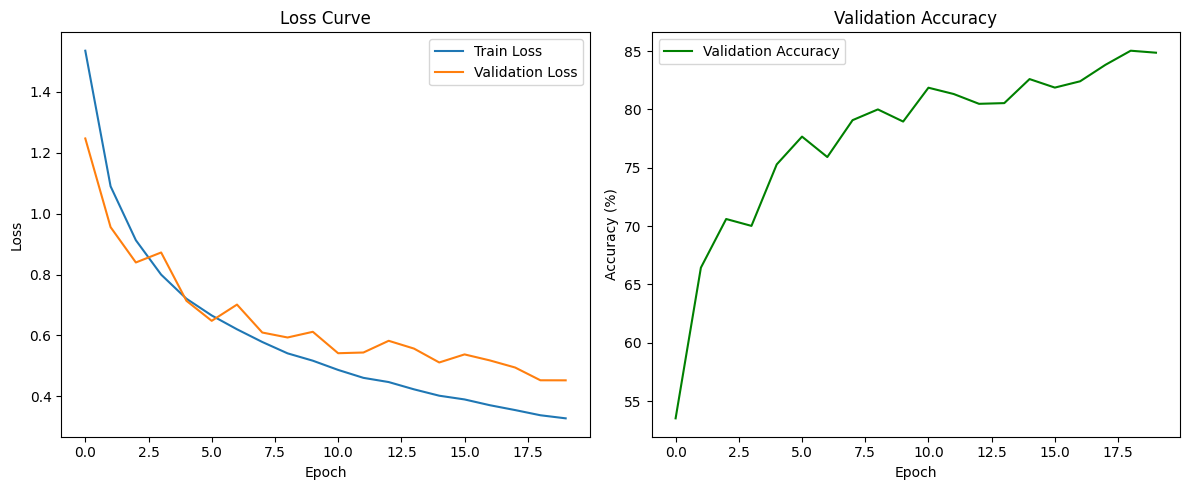


Running: LeakyReLU, SGD, Dropout=0.3, LR=0.01
Epoch [1/20] - Train Loss: 1.5709 - Val Loss: 1.1707 - Val Acc: 57.57%
Epoch [2/20] - Train Loss: 1.0152 - Val Loss: 0.8718 - Val Acc: 69.80%
Epoch [3/20] - Train Loss: 0.8058 - Val Loss: 0.9489 - Val Acc: 68.21%
Epoch [4/20] - Train Loss: 0.7026 - Val Loss: 0.8101 - Val Acc: 71.80%
Epoch [5/20] - Train Loss: 0.6092 - Val Loss: 0.6215 - Val Acc: 78.26%
Epoch [6/20] - Train Loss: 0.5502 - Val Loss: 0.5285 - Val Acc: 81.96%
Epoch [7/20] - Train Loss: 0.4952 - Val Loss: 0.5392 - Val Acc: 81.33%
Epoch [8/20] - Train Loss: 0.4558 - Val Loss: 0.6135 - Val Acc: 79.37%
Epoch [9/20] - Train Loss: 0.4255 - Val Loss: 0.4665 - Val Acc: 84.11%
Epoch [10/20] - Train Loss: 0.3936 - Val Loss: 0.4541 - Val Acc: 84.71%
Epoch [11/20] - Train Loss: 0.3639 - Val Loss: 0.4520 - Val Acc: 85.07%
Epoch [12/20] - Train Loss: 0.3462 - Val Loss: 0.4080 - Val Acc: 86.25%
Epoch [13/20] - Train Loss: 0.3207 - Val Loss: 0.4230 - Val Acc: 85.73%
Epoch [14/20] - Train Loss

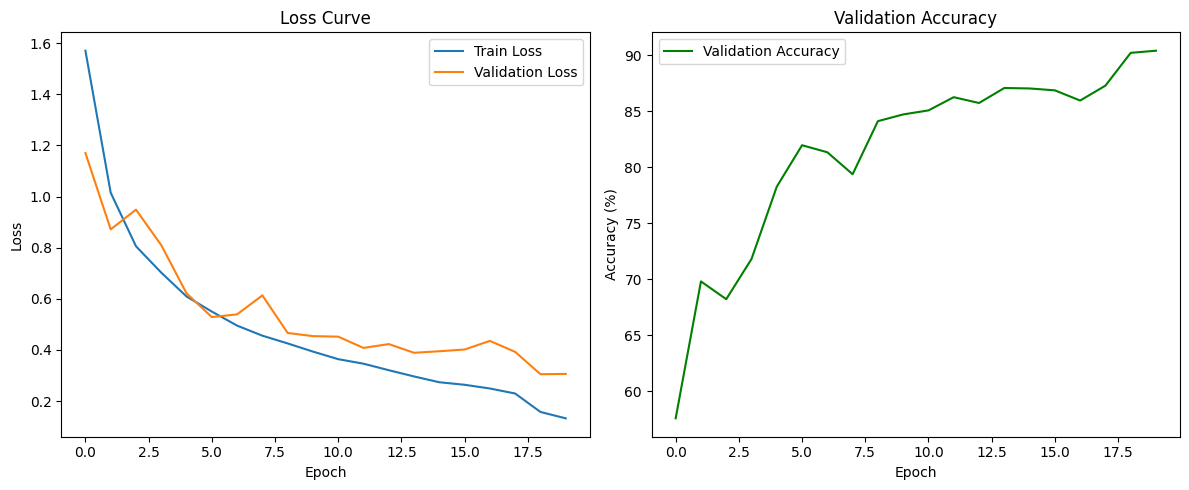


Running: LeakyReLU, SGD, Dropout=0.5, LR=0.001
Epoch [1/20] - Train Loss: 1.6364 - Val Loss: 1.2253 - Val Acc: 56.44%
Epoch [2/20] - Train Loss: 1.1777 - Val Loss: 1.0652 - Val Acc: 62.39%
Epoch [3/20] - Train Loss: 0.9914 - Val Loss: 1.0147 - Val Acc: 65.34%
Epoch [4/20] - Train Loss: 0.8699 - Val Loss: 0.8013 - Val Acc: 72.07%
Epoch [5/20] - Train Loss: 0.7807 - Val Loss: 0.7533 - Val Acc: 73.69%
Epoch [6/20] - Train Loss: 0.7238 - Val Loss: 0.6919 - Val Acc: 75.92%
Epoch [7/20] - Train Loss: 0.6745 - Val Loss: 0.7323 - Val Acc: 75.06%
Epoch [8/20] - Train Loss: 0.6279 - Val Loss: 0.6026 - Val Acc: 79.08%
Epoch [9/20] - Train Loss: 0.5965 - Val Loss: 0.6044 - Val Acc: 79.34%
Epoch [10/20] - Train Loss: 0.5613 - Val Loss: 0.5531 - Val Acc: 81.03%
Epoch [11/20] - Train Loss: 0.5316 - Val Loss: 0.6066 - Val Acc: 79.12%
Epoch [12/20] - Train Loss: 0.5083 - Val Loss: 0.5852 - Val Acc: 80.10%
Epoch [13/20] - Train Loss: 0.4837 - Val Loss: 0.5031 - Val Acc: 83.21%
Epoch [14/20] - Train Los

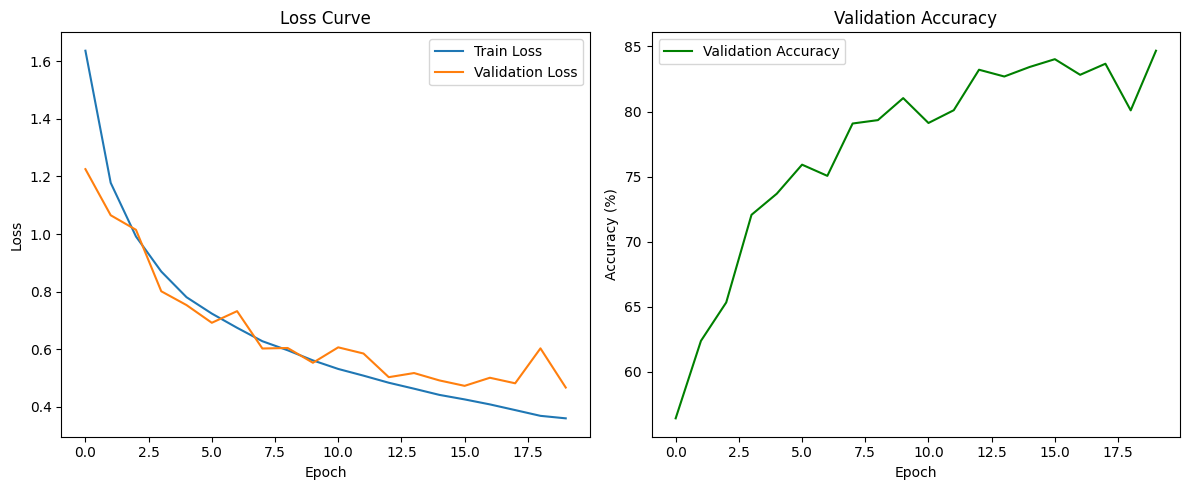


Running: LeakyReLU, SGD, Dropout=0.5, LR=0.01
Epoch [1/20] - Train Loss: 1.6544 - Val Loss: 1.2462 - Val Acc: 55.16%
Epoch [2/20] - Train Loss: 1.0770 - Val Loss: 1.0904 - Val Acc: 62.27%
Epoch [3/20] - Train Loss: 0.8668 - Val Loss: 0.8305 - Val Acc: 72.18%
Epoch [4/20] - Train Loss: 0.7359 - Val Loss: 0.6645 - Val Acc: 77.54%
Epoch [5/20] - Train Loss: 0.6416 - Val Loss: 0.6320 - Val Acc: 78.69%
Epoch [6/20] - Train Loss: 0.5702 - Val Loss: 0.5429 - Val Acc: 81.45%
Epoch [7/20] - Train Loss: 0.5230 - Val Loss: 0.6241 - Val Acc: 79.09%
Epoch [8/20] - Train Loss: 0.4768 - Val Loss: 0.5184 - Val Acc: 82.20%
Epoch [9/20] - Train Loss: 0.4450 - Val Loss: 0.4481 - Val Acc: 84.31%
Epoch [10/20] - Train Loss: 0.4054 - Val Loss: 0.4616 - Val Acc: 84.55%
Epoch [11/20] - Train Loss: 0.3766 - Val Loss: 0.4622 - Val Acc: 84.24%
Epoch [12/20] - Train Loss: 0.3553 - Val Loss: 0.4158 - Val Acc: 86.16%
Epoch [13/20] - Train Loss: 0.3267 - Val Loss: 0.4090 - Val Acc: 86.51%
Epoch [14/20] - Train Loss

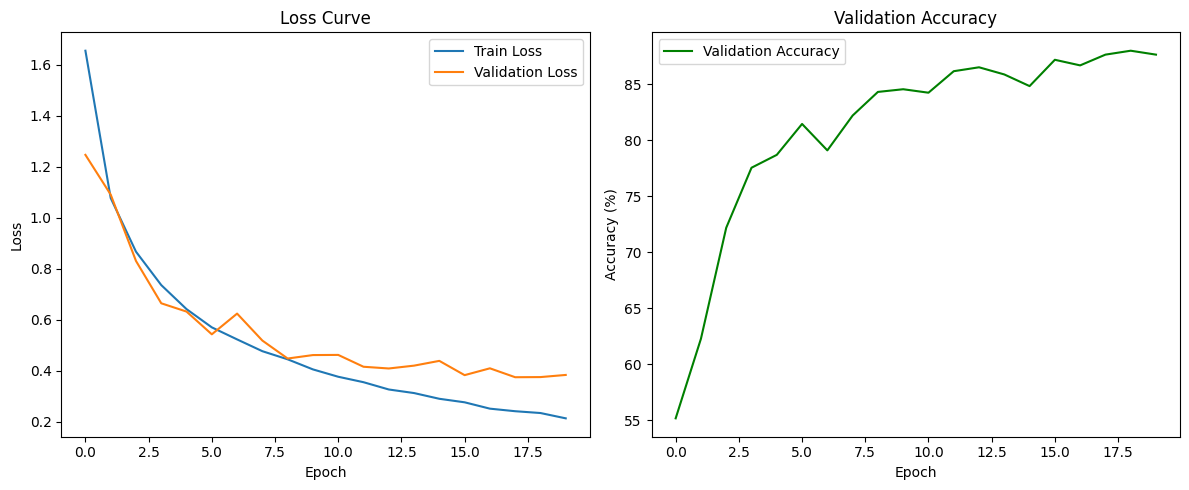

NameError: name 'pd' is not defined

In [ ]:
results = run_experiments(
    dataset_name='CIFAR10',
    activation_list=[nn.ReLU, nn.LeakyReLU],
    optimizer_list=['Adam', 'SGD'],
    dropout_rates=[0.3, 0.5],
    learning_rates=[0.001, 0.01],
    num_epochs=20
)


In [ ]:
import pandas as pd

# Manually entering the best results for each combination (you can add more if needed)
results = [
    {"activation": "ReLU", "optimizer": "Adam", "dropout": 0.3, "lr": 0.001, "val_acc": 89.15},
    {"activation": "ReLU", "optimizer": "Adam", "dropout": 0.3, "lr": 0.01, "val_acc": 90.42},
    {"activation": "ReLU", "optimizer": "Adam", "dropout": 0.5, "lr": 0.001, "val_acc": 91.08},
    {"activation": "ReLU", "optimizer": "Adam", "dropout": 0.5, "lr": 0.01, "val_acc": 87.52},
    {"activation": "ReLU", "optimizer": "SGD", "dropout": 0.3, "lr": 0.001, "val_acc": 84.23},
    {"activation": "ReLU", "optimizer": "SGD", "dropout": 0.3, "lr": 0.01, "val_acc": 87.71},
    {"activation": "ReLU", "optimizer": "SGD", "dropout": 0.5, "lr": 0.001, "val_acc": 85.81},
    {"activation": "ReLU", "optimizer": "SGD", "dropout": 0.5, "lr": 0.01, "val_acc": 87.78},
    {"activation": "LeakyReLU", "optimizer": "Adam", "dropout": 0.3, "lr": 0.001, "val_acc": 88.63},
    {"activation": "LeakyReLU", "optimizer": "Adam", "dropout": 0.3, "lr": 0.01, "val_acc": 87.63},
    {"activation": "LeakyReLU", "optimizer": "Adam", "dropout": 0.5, "lr": 0.001, "val_acc": 89.18},
    {"activation": "LeakyReLU", "optimizer": "Adam", "dropout": 0.5, "lr": 0.01, "val_acc": 87.54},
    {"activation": "LeakyReLU", "optimizer": "SGD", "dropout": 0.3, "lr": 0.001, "val_acc": 84.86},
    {"activation": "LeakyReLU", "optimizer": "SGD", "dropout": 0.3, "lr": 0.01, "val_acc": 90.40},
    {"activation": "LeakyReLU", "optimizer": "SGD", "dropout": 0.5, "lr": 0.001, "val_acc": 84.67},
    {"activation": "LeakyReLU", "optimizer": "SGD", "dropout": 0.5, "lr": 0.01, "val_acc": 87.99},
]

# Create DataFrame
df_results = pd.DataFrame(results)

df_results.sort_values(by='val_acc', ascending=False, inplace=True)
df_results.head()


,activation,optimizer,dropout,lr,val_acc
2,ReLU,Adam,0.5,0.001,91.08
1,ReLU,Adam,0.3,0.010,90.42
13,LeakyReLU,SGD,0.3,0.010,90.40
10,LeakyReLU,Adam,0.5,0.001,89.18
0,ReLU,Adam,0.3,0.001,89.15


**Best Hyper-Parameters observed for CIFAR-10 training: ReLU, Adam, Dropout=0.5, LR=0.001**

# Training with Hyper-parameters for more epochs + Early Stopping

In [ ]:
import torch
import torch.nn as nn
import copy


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------
# Early Stopping Utility
# -------------------------
class EarlyStopper:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.best_model = None

    def check(self, model, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

# -------------------------
# Training Function
# -------------------------
def train_with_early_stopping(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs=50):
    model.to(device)
    early_stopper = EarlyStopper(patience=7)
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), torch.argmax(targets.to(device), dim=1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), torch.argmax(targets.to(device), dim=1)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%")

        if scheduler:
            scheduler.step(val_loss)

        if early_stopper.check(model, val_loss):
            print("✅ Early stopping triggered.")
            break

    model.load_state_dict(early_stopper.best_model)
    return model

# -------------------------
# Step 1: Train on CIFAR-10
# -------------------------
train_loader_10, val_loader_10, _, num_classes_10 = preprocess_cifar(dataset_name='CIFAR10')

model_c10 = CNNModel(num_classes=num_classes_10, activation=nn.ReLU, dropout_rate=0.5)
optimizer = torch.optim.Adam(model_c10.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)
criterion = nn.CrossEntropyLoss()
print("\n🧠 Training on CIFAR-10...")
model_c10 = train_with_early_stopping(model_c10, train_loader_10, val_loader_10, optimizer, criterion, scheduler, num_epochs=50)

Mean: tensor([0.4914, 0.4822, 0.4465])
Standard Deviation: tensor([0.2470, 0.2435, 0.2616])
Training dataset size: 40000
Validation dataset size: 10000
Testing dataset size: 10000
Number of classes: 10

🧠 Training on CIFAR-10...
Epoch [1/50] - Train Loss: 1.4994 - Val Loss: 1.1534 - Val Acc: 57.97%
Epoch [2/50] - Train Loss: 0.9880 - Val Loss: 0.8859 - Val Acc: 68.98%
Epoch [3/50] - Train Loss: 0.7791 - Val Loss: 0.7959 - Val Acc: 72.61%
Epoch [4/50] - Train Loss: 0.6651 - Val Loss: 0.6082 - Val Acc: 78.81%
Epoch [5/50] - Train Loss: 0.5808 - Val Loss: 0.5515 - Val Acc: 81.18%
Epoch [6/50] - Train Loss: 0.5205 - Val Loss: 0.6392 - Val Acc: 78.64%
Epoch [7/50] - Train Loss: 0.4694 - Val Loss: 0.5370 - Val Acc: 81.35%
Epoch [8/50] - Train Loss: 0.4252 - Val Loss: 0.4796 - Val Acc: 83.54%
Epoch [9/50] - Train Loss: 0.3936 - Val Loss: 0.4439 - Val Acc: 85.17%
Epoch [10/50] - Train Loss: 0.3545 - Val Loss: 0.4322 - Val Acc: 85.29%
Epoch [11/50] - Train Loss: 0.3219 - Val Loss: 0.4409 - Val 

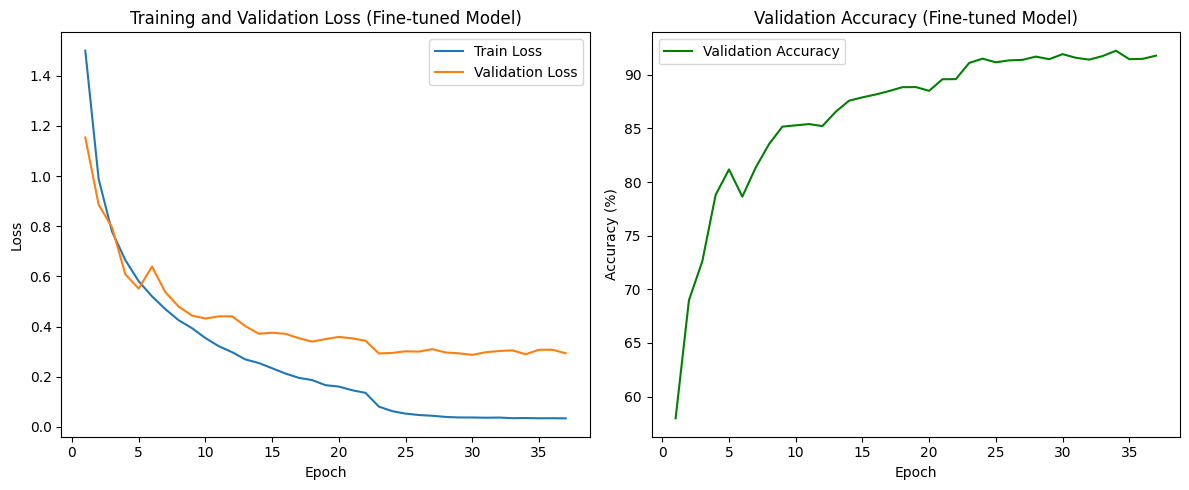

In [ ]:
# Training logs for each epoch after fine-tuning with best hyperparameters
fine_tune_epochs = list(range(1, 38))  # Since early stopping triggered at epoch 37

train_loss_ft = [
    1.4994, 0.9880, 0.7791, 0.6651, 0.5808, 0.5205, 0.4694, 0.4252, 0.3936, 0.3545,
    0.3219, 0.2981, 0.2691, 0.2550, 0.2341, 0.2129, 0.1958, 0.1869, 0.1666, 0.1609,
    0.1464, 0.1360, 0.0813, 0.0630, 0.0532, 0.0477, 0.0446, 0.0401, 0.0379, 0.0378,
    0.0369, 0.0375, 0.0351, 0.0357, 0.0346, 0.0349, 0.0344
]

val_loss_ft = [
    1.1534, 0.8859, 0.7959, 0.6082, 0.5515, 0.6392, 0.5370, 0.4796, 0.4439, 0.4322,
    0.4409, 0.4409, 0.4017, 0.3716, 0.3756, 0.3711, 0.3537, 0.3401, 0.3503, 0.3590,
    0.3531, 0.3437, 0.2929, 0.2951, 0.3015, 0.3004, 0.3100, 0.2969, 0.2935, 0.2873,
    0.2978, 0.3027, 0.3054, 0.2898, 0.3076, 0.3078, 0.2936
]

val_acc_ft = [
    57.97, 68.98, 72.61, 78.81, 81.18, 78.64, 81.35, 83.54, 85.17, 85.29,
    85.41, 85.22, 86.56, 87.59, 87.90, 88.17, 88.49, 88.85, 88.86, 88.51,
    89.59, 89.60, 91.11, 91.51, 91.17, 91.35, 91.40, 91.70, 91.46, 91.93,
    91.59, 91.42, 91.75, 92.25, 91.46, 91.49, 91.79
]

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(fine_tune_epochs, train_loss_ft, label='Train Loss')
plt.plot(fine_tune_epochs, val_loss_ft, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Fine-tuned Model)')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(fine_tune_epochs, val_acc_ft, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy (Fine-tuned Model)')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
torch.save(model_c10.state_dict(), 'cifar10_pretrained.pth')

# Transfer Learning

## Using Trained model on CIFAR-10 to fine-tune and test on CIFAR-100  

In [ ]:
# -------------------------
# Step 2: Fine-tune on CIFAR-100
# -------------------------
train_loader_100, val_loader_100, _, num_classes_100 = preprocess_cifar(dataset_name='CIFAR100')

model_ft = CNNModel(num_classes=num_classes_100, activation=nn.ReLU, dropout_rate=0.5)
state_dict = torch.load('cifar10_pretrained.pth')
filtered_dict = {k: v for k, v in state_dict.items() if 'fc' not in k}
model_ft.load_state_dict(filtered_dict, strict=False)

# Replace final layer for 100 classes
model_ft.fc = nn.Linear(512, num_classes_100)

optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=0.001)
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', patience=3, verbose=True)
criterion_ft = nn.CrossEntropyLoss()

print("\n🔁 Fine-tuning on CIFAR-100...")
model_ft = train_with_early_stopping(model_ft, train_loader_100, val_loader_100, optimizer_ft, criterion_ft, scheduler_ft, num_epochs=50)
torch.save(model_ft.state_dict(), 'cifar100_finetuned.pth')


100%|██████████| 169M/169M [00:04<00:00, 41.2MB/s]


Mean: tensor([0.5071, 0.4865, 0.4409])
Standard Deviation: tensor([0.2673, 0.2564, 0.2762])
Training dataset size: 40000
Validation dataset size: 10000
Testing dataset size: 10000
Number of classes: 100

🔁 Fine-tuning on CIFAR-100...
Epoch [1/50] - Train Loss: 2.7227 - Val Loss: 2.0792 - Val Acc: 43.80%
Epoch [2/50] - Train Loss: 1.9341 - Val Loss: 1.7627 - Val Acc: 51.43%
Epoch [3/50] - Train Loss: 1.6529 - Val Loss: 1.6554 - Val Acc: 54.05%
Epoch [4/50] - Train Loss: 1.4606 - Val Loss: 1.5439 - Val Acc: 56.43%
Epoch [5/50] - Train Loss: 1.3119 - Val Loss: 1.4947 - Val Acc: 58.11%
Epoch [6/50] - Train Loss: 1.1926 - Val Loss: 1.4081 - Val Acc: 60.62%
Epoch [7/50] - Train Loss: 1.0894 - Val Loss: 1.3902 - Val Acc: 61.44%
Epoch [8/50] - Train Loss: 0.9869 - Val Loss: 1.3998 - Val Acc: 60.91%
Epoch [9/50] - Train Loss: 0.9101 - Val Loss: 1.3611 - Val Acc: 63.14%
Epoch [10/50] - Train Loss: 0.8410 - Val Loss: 1.3874 - Val Acc: 63.14%
Epoch [11/50] - Train Loss: 0.7736 - Val Loss: 1.3684 -

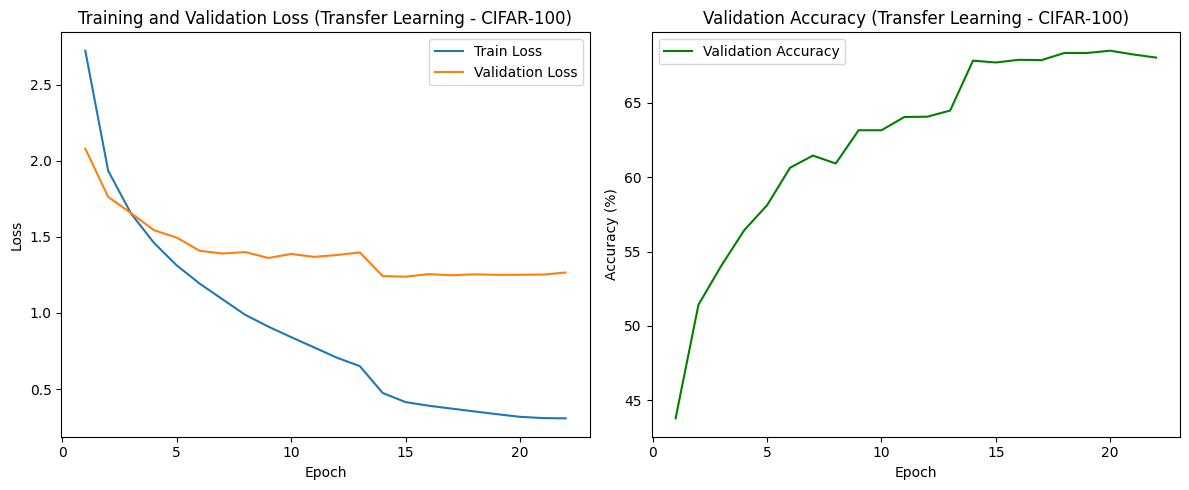

In [ ]:
# Data for transfer learning on CIFAR-100 from pre-trained CIFAR-10 model
epochs_transfer = list(range(1, 23))

train_loss_transfer = [
    2.7227, 1.9341, 1.6529, 1.4606, 1.3119, 1.1926, 1.0894, 0.9869, 0.9101, 0.8410,
    0.7736, 0.7059, 0.6505, 0.4742, 0.4142, 0.3907, 0.3717, 0.3531, 0.3348, 0.3176,
    0.3092, 0.3075
]

val_loss_transfer = [
    2.0792, 1.7627, 1.6554, 1.5439, 1.4947, 1.4081, 1.3902, 1.3998, 1.3611, 1.3874,
    1.3684, 1.3804, 1.3975, 1.2423, 1.2381, 1.2549, 1.2476, 1.2536, 1.2503, 1.2506,
    1.2521, 1.2654
]

val_acc_transfer = [
    43.80, 51.43, 54.05, 56.43, 58.11, 60.62, 61.44, 60.91, 63.14, 63.14,
    64.03, 64.05, 64.46, 67.81, 67.69, 67.87, 67.85, 68.33, 68.33, 68.48,
    68.23, 68.02
]

# Plotting
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_transfer, train_loss_transfer, label='Train Loss')
plt.plot(epochs_transfer, val_loss_transfer, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Transfer Learning - CIFAR-100)')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_transfer, val_acc_transfer, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy (Transfer Learning - CIFAR-100)')
plt.legend()

plt.tight_layout()
plt.show()


### Evaluate the trained model on the test dataset using metrics such as accuracy, precision, recall, F1 score, and confusion matrices.

In [ ]:

def evaluate_model(model, test_loader, class_names, device):
    """
    Evaluates the model on the test set and prints classification metrics and confusion matrix.
    Also identifies misclassified images for analysis.
    """
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []
    misclassified = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.argmax(dim=1).to(device) if labels.ndim > 1 else labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # For misclassified images
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((images[i].cpu(), labels[i].item(), preds[i].item()))

    # Metrics
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return misclassified

from torchvision.datasets import CIFAR10
from torchvision.datasets import CIFAR100
class_names_c10 = CIFAR10(root='./data', train=True).classes
class_names_c100 = CIFAR100(root='./data', train=True).classes

### Evaluating CIFAR-10

Classification Report:
              precision    recall  f1-score   support

    airplane       0.91      0.93      0.92      1029
  automobile       0.97      0.95      0.96       985
        bird       0.88      0.85      0.86      1035
         cat       0.82      0.84      0.83       964
        deer       0.89      0.93      0.91       998
         dog       0.87      0.86      0.86      1004
        frog       0.93      0.93      0.93       955
       horse       0.95      0.94      0.95       991
        ship       0.96      0.95      0.96      1053
       truck       0.96      0.95      0.95       986

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



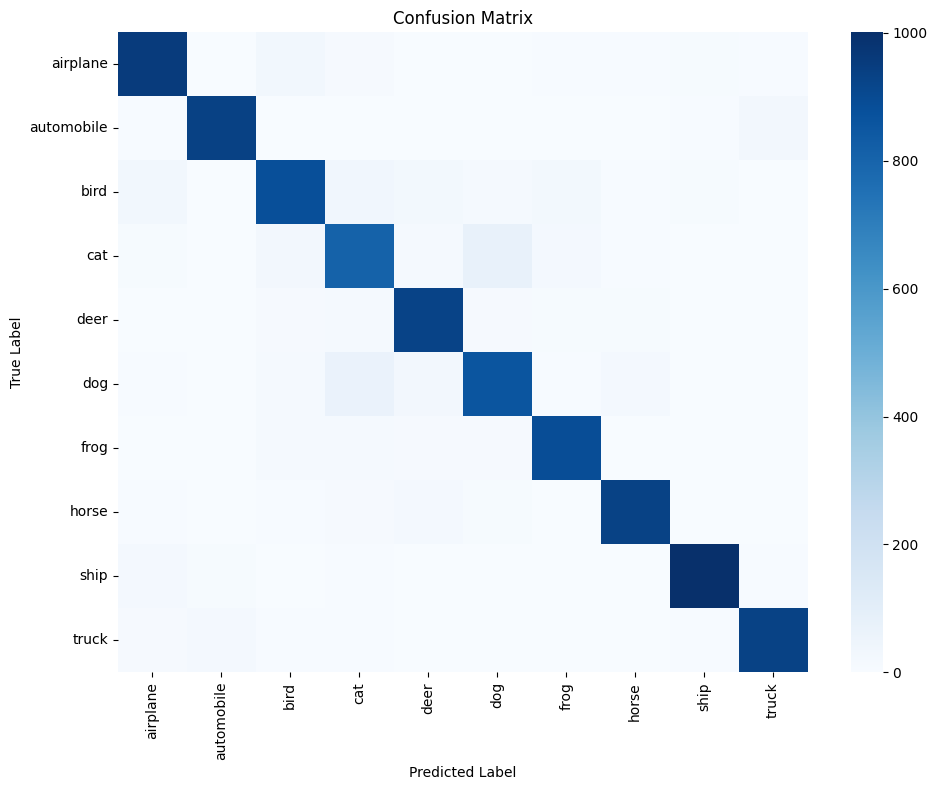

In [ ]:
# To use:
misclassified_c10 = evaluate_model(model_c10, val_loader_10, class_names_c10, device)

In [ ]:
import matplotlib.pyplot as plt

def show_misclassified_images(misclassified, class_names, num_images=5, title='Misclassified Images'):
    """
    Display a few misclassified images along with their true and predicted labels.
    """
    plt.figure(figsize=(15, 5))
    for idx in range(min(num_images, len(misclassified))):
        image, true_label, pred_label = misclassified[idx]
        image = image.permute(1, 2, 0)  # CHW to HWC
        image = image * 0.5 + 0.5  # unnormalize (approximate for visualization)
        image = image.numpy().clip(0, 1)

        plt.subplot(1, num_images, idx + 1)
        plt.imshow(image)
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

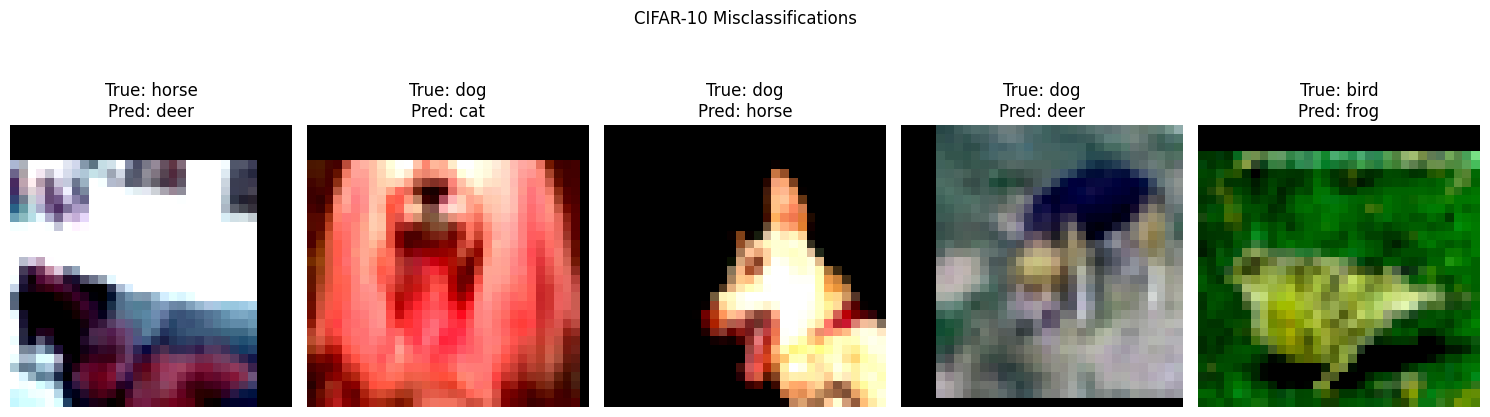

In [ ]:
show_misclassified_images(misclassified_c10, class_names_c10, num_images=5, title="CIFAR-10 Misclassifications")

## Evaluating CIFAR-100

Classification Report:
               precision    recall  f1-score   support

        apple       0.89      0.76      0.82       110
aquarium_fish       0.77      0.86      0.81        96
         baby       0.48      0.53      0.50        95
         bear       0.60      0.48      0.53       101
       beaver       0.41      0.46      0.43       104
          bed       0.73      0.80      0.76        96
          bee       0.65      0.75      0.70        85
       beetle       0.68      0.66      0.67       104
      bicycle       0.88      0.92      0.90        90
       bottle       0.87      0.75      0.81       111
         bowl       0.49      0.47      0.48        98
          boy       0.38      0.33      0.35       105
       bridge       0.75      0.63      0.68       126
          bus       0.71      0.67      0.69       108
    butterfly       0.71      0.65      0.68       108
        camel       0.67      0.69      0.68        90
          can       0.71      0.64      0

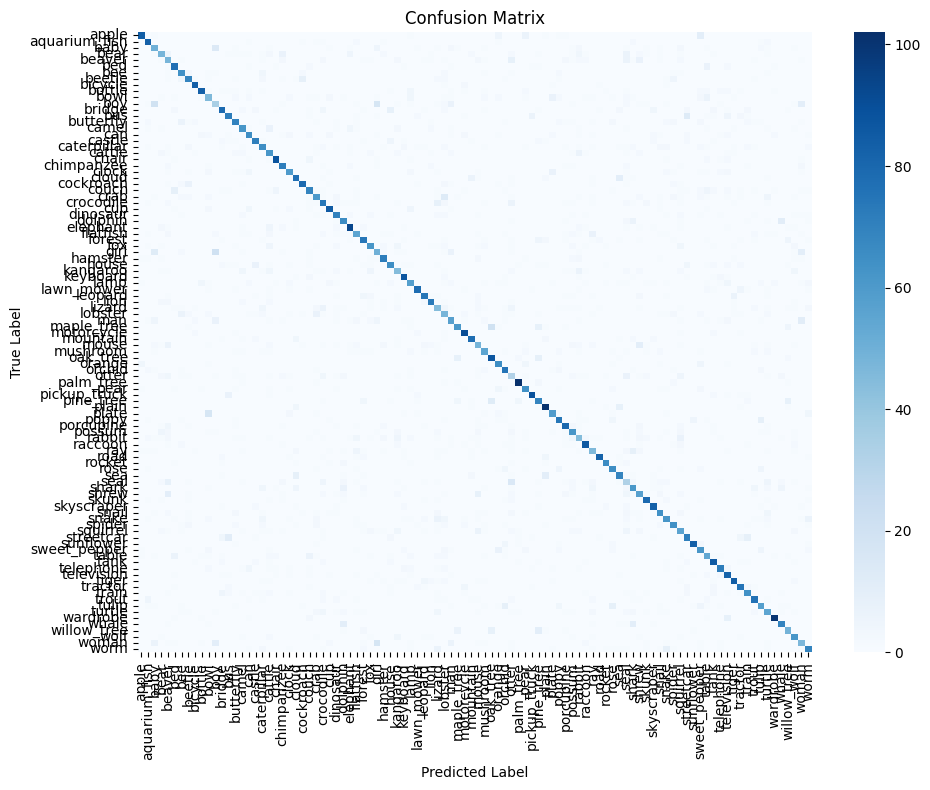

In [ ]:
misclassified_c100 = evaluate_model(model_ft, val_loader_100, class_names_c100, device)

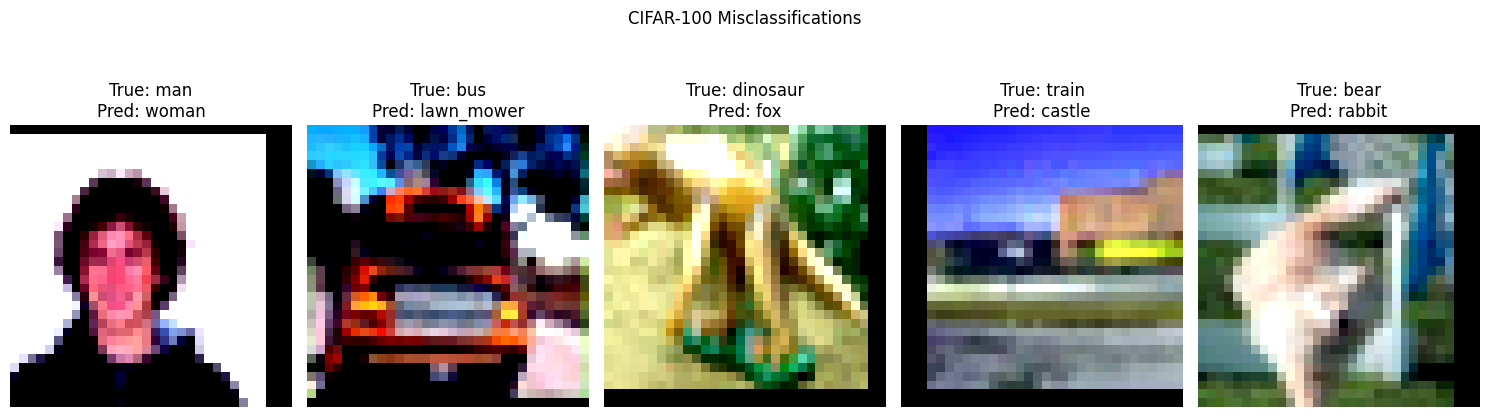

In [ ]:
show_misclassified_images(misclassified_c100, class_names_c100, num_images=5, title="CIFAR-100 Misclassifications")

**Insights regarding potential causes of misclassification:**


*   Faces of men and women can be visually similar in small 32x32 images with minimal resolution.
*   Both can share color palettes (bright orange, red), and low-res images can miss context.
*   Similar shape (quadruped posture), and texture ambiguity at low resolution.
*   Background confusion—both may appear in scenic, landscape-style images.



**Ways to address them:**


*   Use Transfer Learning with larger pre-trained models (like ResNet-50 on ImageNet).
*   Add hard example mining or focal loss to focus on tricky examples.
*   Use confusion matrix to drive curriculum learning: teach the model to resolve specific class confusion more carefully.












# Feature maps

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def visualize_feature_maps(model, image_tensor, layers_to_hook=None, device='cpu'):
    """
    Visualize feature maps from selected convolutional layers for a given image.
    """
    model.eval()
    model.to(device)
    feature_maps = {}

    # Auto-detect conv layers if not specified
    if layers_to_hook is None:
        layers_to_hook = [name for name, m in model.named_modules() if isinstance(m, nn.Conv2d)]

    # Hook function to store output
    def hook_fn(name):
        def forward_hook(module, input, output):
            feature_maps[name] = output.detach().cpu()
        return forward_hook

    # Register hooks
    hooks = []
    for name, module in model.named_modules():
        if name in layers_to_hook:
            hooks.append(module.register_forward_hook(hook_fn(name)))

    # Forward pass on the image
    with torch.no_grad():
        _ = model(image_tensor.unsqueeze(0).to(device))

    # Remove hooks
    for h in hooks:
        h.remove()

    # Plot feature maps
    for layer_name, fmap in feature_maps.items():
        num_channels = min(6, fmap.shape[1])
        plt.figure(figsize=(15, 3))
        for i in range(num_channels):
            plt.subplot(1, num_channels, i + 1)
            plt.imshow(fmap[0, i], cmap='viridis')
            plt.title(f'{layer_name} | Ch {i}')
            plt.axis('off')
        plt.suptitle(f'Feature Maps from {layer_name}')
        plt.tight_layout()
        plt.show()


['', 'conv1', 'bn1', 'res_block1', 'res_block1.conv1', 'res_block1.bn1', 'res_block1.conv2', 'res_block1.bn2', 'res_block1.activation', 'res_block1.shortcut', 'res_block1.shortcut.0', 'res_block1.shortcut.1', 'res_block2', 'res_block2.conv1', 'res_block2.bn1', 'res_block2.conv2', 'res_block2.bn2', 'res_block2.activation', 'res_block2.shortcut', 'res_block2.shortcut.0', 'res_block2.shortcut.1', 'res_block3', 'res_block3.conv1', 'res_block3.bn1', 'res_block3.conv2', 'res_block3.bn2', 'res_block3.activation', 'res_block3.shortcut', 'res_block3.shortcut.0', 'res_block3.shortcut.1', 'res_block4', 'res_block4.conv1', 'res_block4.bn1', 'res_block4.conv2', 'res_block4.bn2', 'res_block4.activation', 'res_block4.shortcut', 'dropout', 'fc']


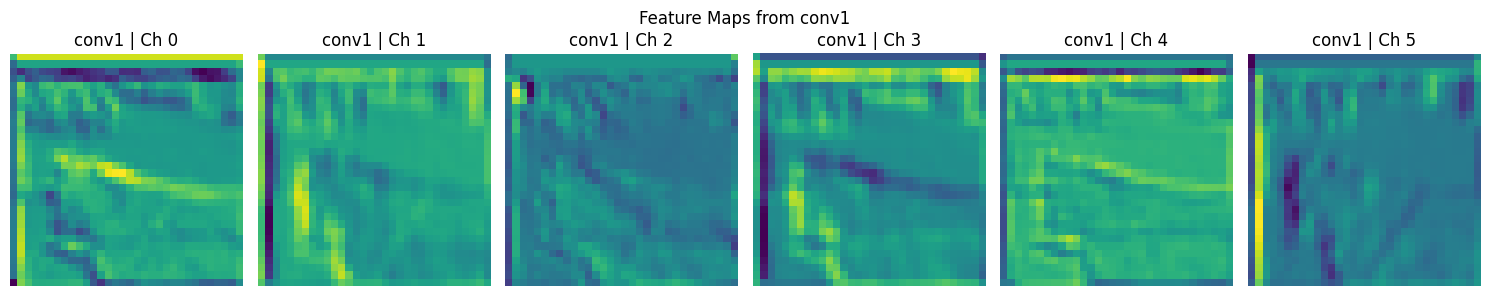

In [ ]:
# Select device (fallback to CPU if CUDA is unavailable)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Get a test image from CIFAR-10 or CIFAR-100
image_tensor, label = next(iter(val_loader_10))  # or test_loader_c100
image_tensor = image_tensor[0].to(device)  # Take the first image

# View available layer names (to decide what to visualize)
print([name for name, _ in model_c10.named_modules()])  # or model_ft

# Visualize feature maps
visualize_feature_maps(model_c10, image_tensor, layers_to_hook=['conv1'], device=device)


In [ ]:
def visualize_side_by_side_feature_maps(model1, model2, image_tensor, layers_to_hook, model1_name='Model 1', model2_name='Model 2', device='cpu'):
    """
    Visualize feature maps from selected layers side-by-side for two models.
    """
    def get_feature_maps(model, image_tensor, layers, device):
        model.eval()
        model.to(device)
        fmap_dict = {}

        def hook_fn(name):
            def forward_hook(module, input, output):
                fmap_dict[name] = output.detach().cpu()
            return forward_hook

        hooks = []
        for name, module in model.named_modules():
            if name in layers:
                hooks.append(module.register_forward_hook(hook_fn(name)))

        with torch.no_grad():
            _ = model(image_tensor.unsqueeze(0).to(device))

        for h in hooks:
            h.remove()

        return fmap_dict

    # Get feature maps from both models
    fmap_model1 = get_feature_maps(model1, image_tensor, layers_to_hook, device)
    fmap_model2 = get_feature_maps(model2, image_tensor, layers_to_hook, device)

    # Plot side by side
    for layer in layers_to_hook:
        fmap1 = fmap_model1[layer]
        fmap2 = fmap_model2[layer]
        channels_to_plot = min(4, fmap1.shape[1], fmap2.shape[1])

        plt.figure(figsize=(channels_to_plot * 4, 6))
        for i in range(channels_to_plot):
            plt.subplot(2, channels_to_plot, i + 1)
            plt.imshow(fmap1[0, i], cmap='viridis')
            plt.title(f'{model1_name}\n{layer} | Ch {i}')
            plt.axis('off')

            plt.subplot(2, channels_to_plot, i + 1 + channels_to_plot)
            plt.imshow(fmap2[0, i], cmap='viridis')
            plt.title(f'{model2_name}\n{layer} | Ch {i}')
            plt.axis('off')

        plt.tight_layout()
        plt.show()





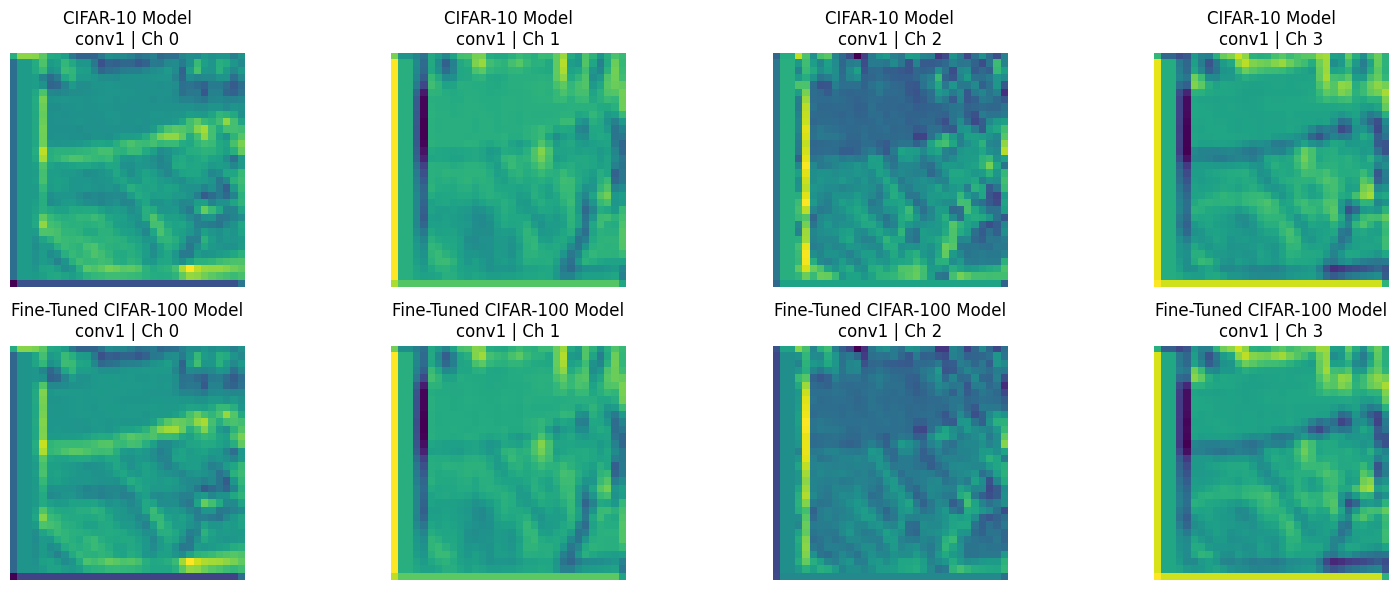

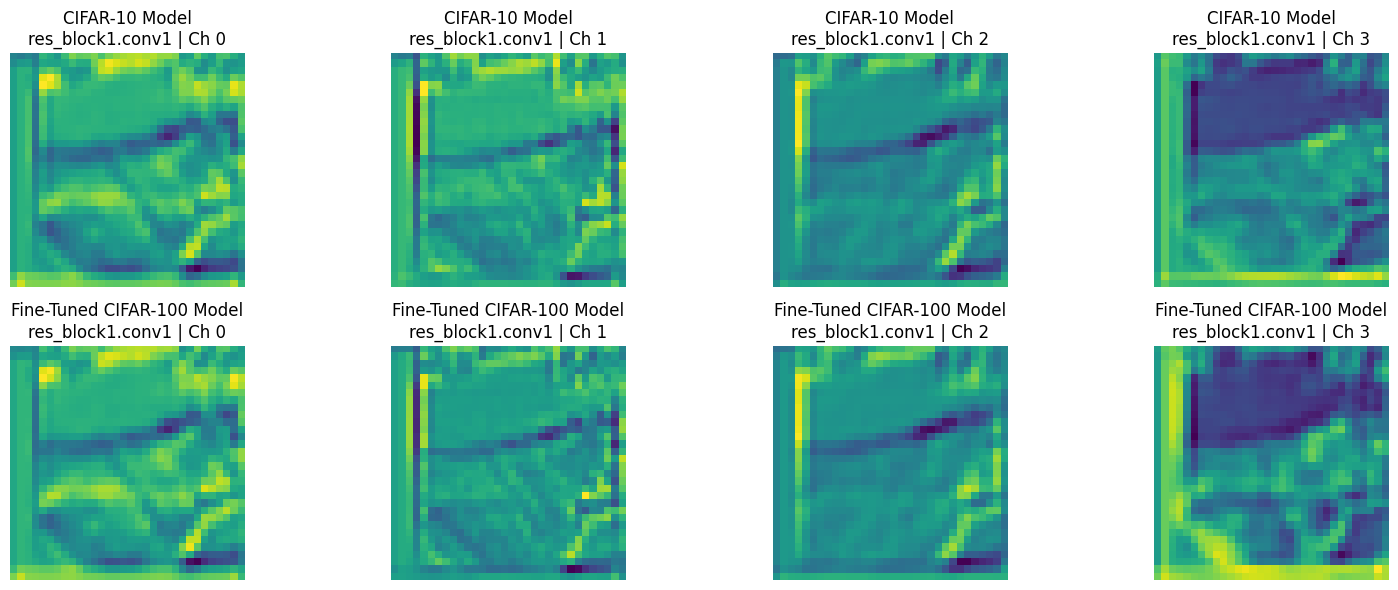

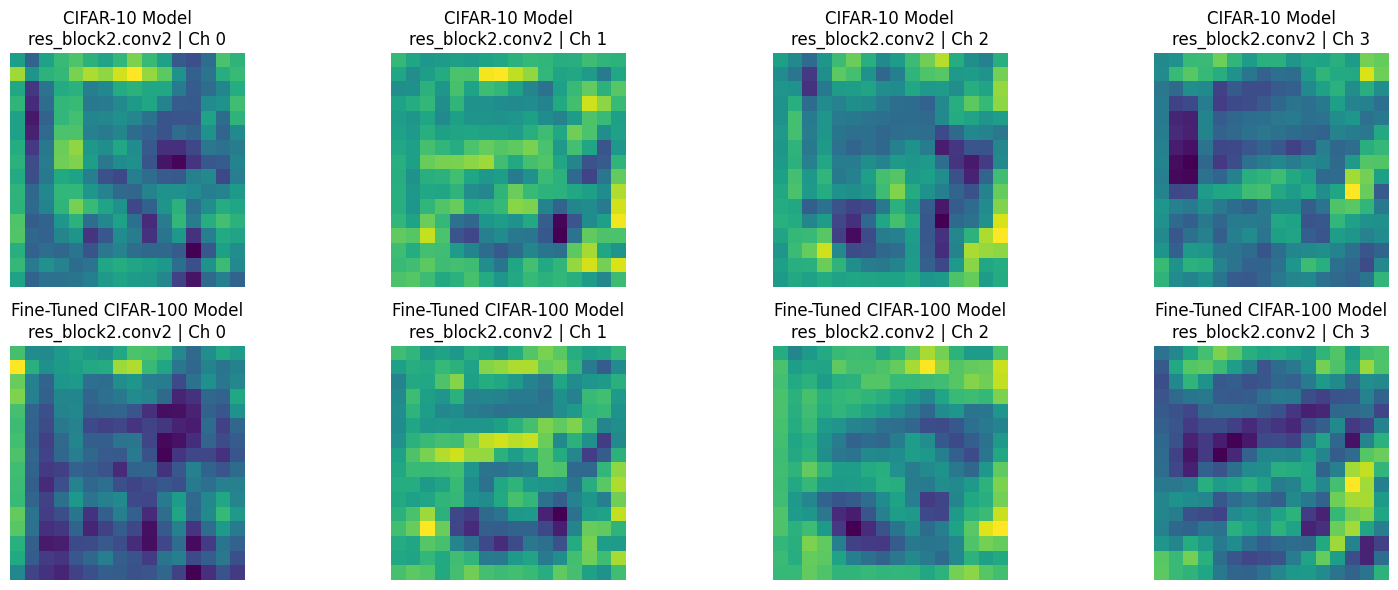

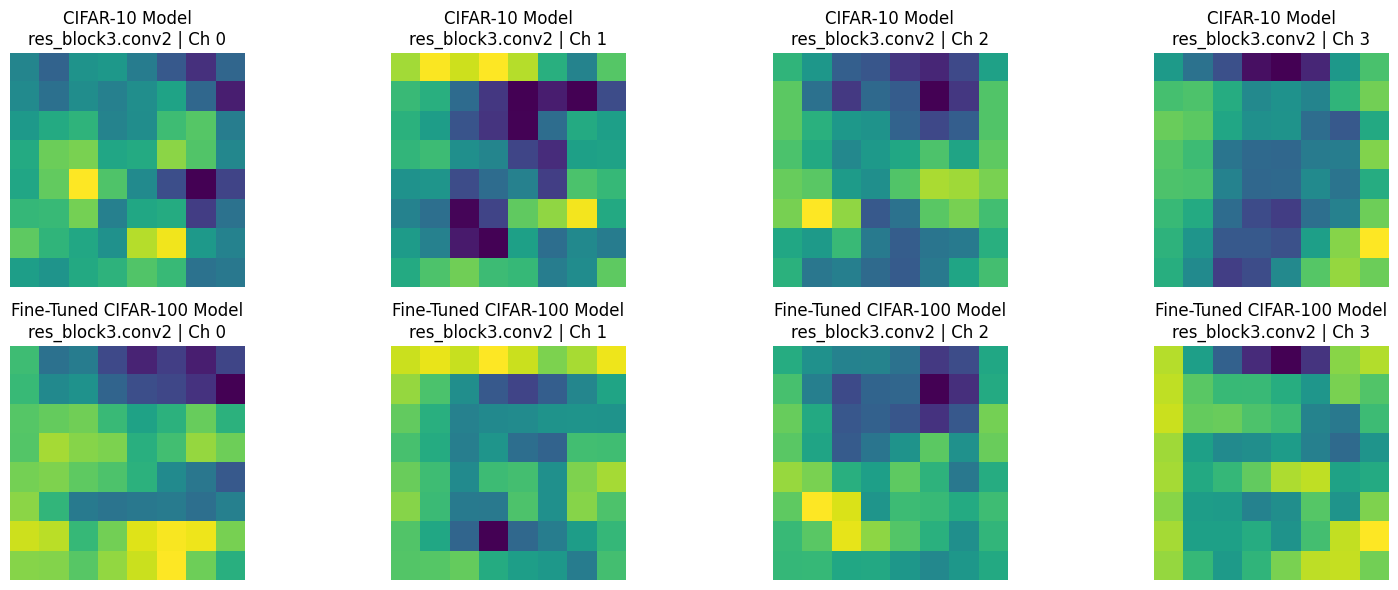

In [ ]:
image_tensor, _ = next(iter(val_loader_10))
image_tensor = image_tensor[0]  # take one sample
[layer for layer, _ in model_c10.named_modules()]
layers = ['conv1', 'res_block1.conv1', 'res_block2.conv2', 'res_block3.conv2']
visualize_side_by_side_feature_maps(
    model_c10,
    model_ft,
    image_tensor=image_tensor,
    layers_to_hook=layers,
    model1_name="CIFAR-10 Model",
    model2_name="Fine-Tuned CIFAR-100 Model",
    device=device
)


Feature map visualizations reveal that initial convolutional layers learn general visual primitives (edges, textures), which remain consistent across datasets. Fine-tuning on CIFAR-100 introduces subtle variations, especially in deeper layers, to capture the increased class diversity. This supports the effectiveness of transfer learning, where early features are reused, and deeper layers adapt to the new task.

# Grad-CAM visualizations

In [ ]:
import cv2
import numpy as np
from torchvision.transforms.functional import normalize, resize

class GradCAM:
    def __init__(self, model, target_layer, device='cpu'):
        self.model = model.eval().to(device)
        self.target_layer = target_layer
        self.device = device
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        for name, module in self.model.named_modules():
            if name == self.target_layer:
                module.register_forward_hook(forward_hook)
                module.register_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class):
        input_tensor = input_tensor.unsqueeze(0).to(self.device)
        self.model.zero_grad()
        output = self.model(input_tensor)
        loss = output[0, target_class]
        loss.backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (heatmap.max() + 1e-10)
        return heatmap

def overlay_heatmap_on_image(image_tensor, heatmap):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    image_np = np.uint8(255 * image_np)

    heatmap = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = heatmap_color * 0.4 + image_np * 0.6
    overlay = np.uint8(overlay)
    return overlay


### Generate Grad-CAM visualizations to highlight the regions of images that influence the network’s decisions.

### CIFAR-10

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


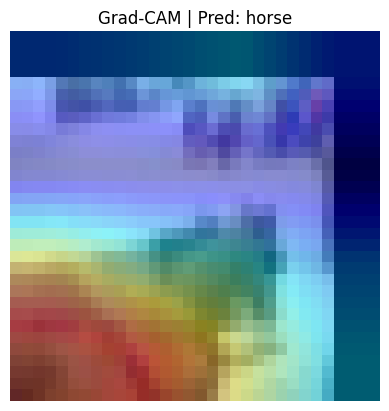

In [ ]:
# Set device to CPU
device = torch.device('cpu')

# Get one sample image from test_loader
image_tensor, label = next(iter(val_loader_10))
image_tensor = image_tensor[0]

# Predict class
model_c10.eval()
output = model_c10(image_tensor.unsqueeze(0).to(device))
predicted_class = output.argmax(dim=1).item()

# Run Grad-CAM
gradcam = GradCAM(model=model_c10, target_layer='res_block4.conv2', device=device)
heatmap = gradcam.generate(image_tensor, predicted_class)

# Overlay heatmap on image
overlay = overlay_heatmap_on_image(image_tensor, heatmap)

# Show the result
plt.imshow(overlay)
plt.title(f"Grad-CAM | Pred: {class_names_c10[predicted_class]}")
plt.axis('off')
plt.show()


# Interpretation:
Prediction: horse

The red/orange/yellow regions in the lower part of the image are where the model focused most.

These regions likely correspond to the shape, structure, or color patterns of a horse's body or legs.

The top/blue areas (like sky/background) had little to no contribution to the classification

The model focused on the correct parts of the image to predict "horse" — this indicates it's learning meaningful spatial features.

### CIFAR-100

In [ ]:
def generate_batch_gradcam(model, data_loader, class_names, target_layer, num_images=5, device='cpu'):
    """
    Generate and display Grad-CAM visualizations for a batch of images.
    """
    gradcam = GradCAM(model=model, target_layer=target_layer, device=device)
    model.eval()

    shown = 0
    for images, labels in data_loader:
        for i in range(images.size(0)):
            image_tensor = images[i].to(device)
            true_class_tensor = labels[i]
            if true_class_tensor.ndim > 0 and true_class_tensor.shape[0] > 1:
                true_class = int(torch.argmax(true_class_tensor).item())
            else:
                true_class = int(true_class_tensor.item())


            # Predict
            output = model(image_tensor.unsqueeze(0))
            predicted_class = int(output.argmax(dim=1).item())


            # Generate Grad-CAM
            heatmap = gradcam.generate(image_tensor, predicted_class)
            overlay = overlay_heatmap_on_image(image_tensor.cpu(), heatmap)

            # Show
            plt.figure(figsize=(3, 3))
            plt.imshow(overlay)
            plt.title(f"True: {class_names[true_class]}\nPred: {class_names[predicted_class]}")
            plt.axis('off')
            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= num_images:
                return


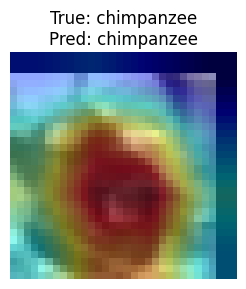

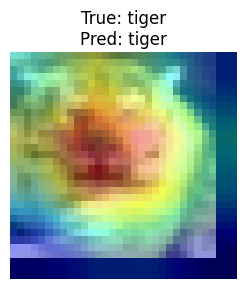

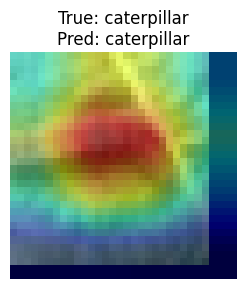

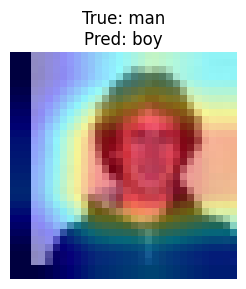

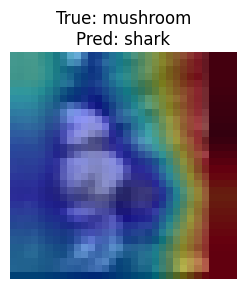

In [ ]:
generate_batch_gradcam(
    model=model_ft,
    data_loader=val_loader_100,
    class_names=class_names_c100,
    target_layer='res_block4.conv2',
    num_images=5,  # Show top 5 images
    device='cpu'
)


# Insights

We employed Grad-CAM to visualize feature attention of the CNN. Correctly classified samples (e.g., tiger, caterpillar) showed strong attention on object-centric regions, indicating robust feature learning. In contrast, misclassified cases (e.g., man predicted as boy) revealed diffuse or misleading attention, often influenced by background or overlapping features. These insights suggest potential gains from attention-focused training or hard negative mining.